# Bank Churn Prediction - Project Step 1

**By Sandy TEFOUEGOUM Group 9 ML Project**

**Objective:** Build a baseline model to predict bank customer churn

---

## Table of Contents

1. [Data Loading and Initial Exploration](#1)
2. [Descriptive Analysis](#2)
3. [Data Preprocessing](#3)
4. [Problem Formalization](#4)
5. [Baseline Model](#5)


<a id='1'></a>
## 1. Data Loading and Initial Exploration

### 1.1 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

np.random.seed(42)

print("Libraries imported")

Libraries imported


### 1.2 Load the Dataset

In [2]:
df = pd.read_csv('C:/Users/sandy/Documents/bank-churn-prediction/data/raw/archive/BankChurners.csv')

print("Dataset loaded/")
print(f"Original shape: {df.shape}")

# Remove unnecessary columns 
columns_to_drop = [col for col in df.columns if 'Naive_Bayes' in col]

if columns_to_drop:
    print(f"\nRemoving {len(columns_to_drop)} unnecessary columns:")
    for col in columns_to_drop:
        print(f"  - {col}")
    df = df.drop(columns=columns_to_drop)

print(f"\nCleaned shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded/
Original shape: (10127, 23)

Removing 2 unnecessary columns:
  - Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1
  - Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2

Cleaned shape: (10127, 21)
Number of rows: 10127
Number of columns: 21


### 1.3 First Look at the Data

In [3]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [5]:
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values.")

Missing values per column:
Series([], dtype: int64)

No missing values.


### Analysis of Initial Exploration


 Based on this initial exploration we can observe that the dataset contains 10127 rows and 21 columns. We only have numerical features; There is no missing values; The target variable is likely "Attrition_Flag". There were some columns which were generated automaitically and had no values so i had to remove them.

---
<a id='2'></a>
## 2. Descriptive Analysis

### 2.1 Target Variable Analysis

In [3]:
print("Target Variable: Attrition_Flag")
target_counts = df['Attrition_Flag'].value_counts()
target_percentages = df['Attrition_Flag'].value_counts(normalize=True) * 100

print("\nClass Distribution:")
for label, count in target_counts.items():
    pct = target_percentages[label]
    print(f"  {label}: {count} ({pct:.2f}%)")

# Calculate imbalance ratio
majority = target_counts.max()
minority = target_counts.min()
imbalance_ratio = majority / minority

print(f"\nImbalance Ratio: 1:{imbalance_ratio:.2f}")

# Determine severity
if imbalance_ratio <= 2:
    severity = "WEAK"
elif imbalance_ratio <= 10:
    severity = "MODERATE"
else:
    severity = "SEVERE"
    
print(f"Imbalance Severity: {severity}")

Target Variable: Attrition_Flag

Class Distribution:
  Existing Customer: 8500 (83.93%)
  Attrited Customer: 1627 (16.07%)

Imbalance Ratio: 1:5.22
Imbalance Severity: MODERATE


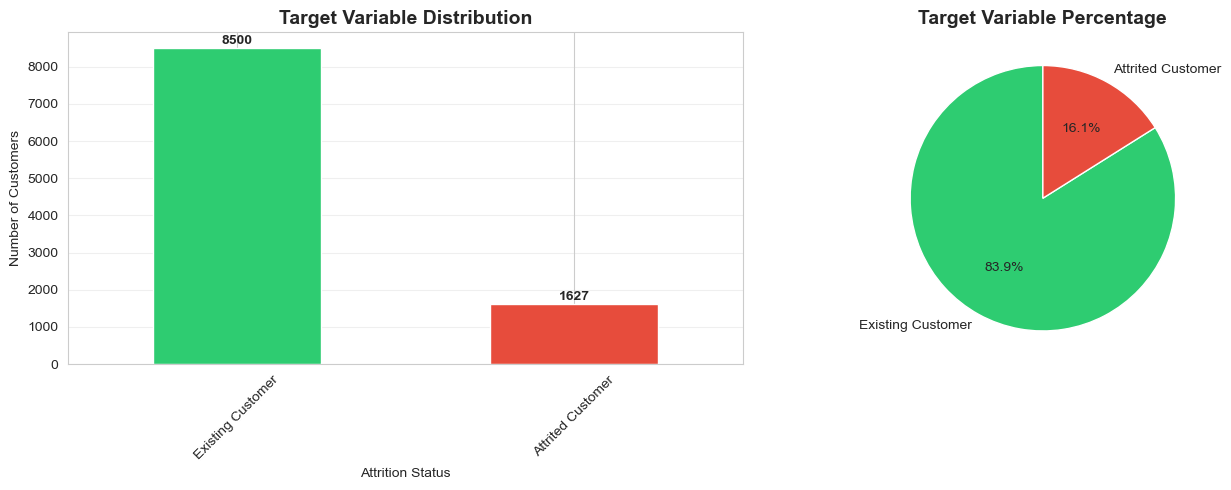

In [7]:
#visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].grid(axis='y', alpha=0.3)


for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Target Variable Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Statistical Summary

In [8]:
# column types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from categorical
if 'Attrition_Flag' in categorical_cols:
    categorical_cols.remove('Attrition_Flag')

print(f"Numerical features: {len(numerical_cols)}")
print(numerical_cols)
print()
print(f"Categorical features: {len(categorical_cols)}")
print(categorical_cols)

Numerical features: 15
['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Categorical features: 5
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [9]:
print("Statistical Summary of Numerical Features:")
df[numerical_cols].describe().T

Statistical Summary of Numerical Features:


,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


In [10]:
print("Categorical Features Analysis:")

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

Categorical Features Analysis:

Gender:
Gender
F    5358
M    4769
Name: count, dtype: int64
Unique values: 2

Education_Level:
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64
Unique values: 7

Marital_Status:
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64
Unique values: 4

Income_Category:
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64
Unique values: 6

Card_Category:
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64
Unique values: 4


### 2.3 Distribution Visualization - Numerical Features

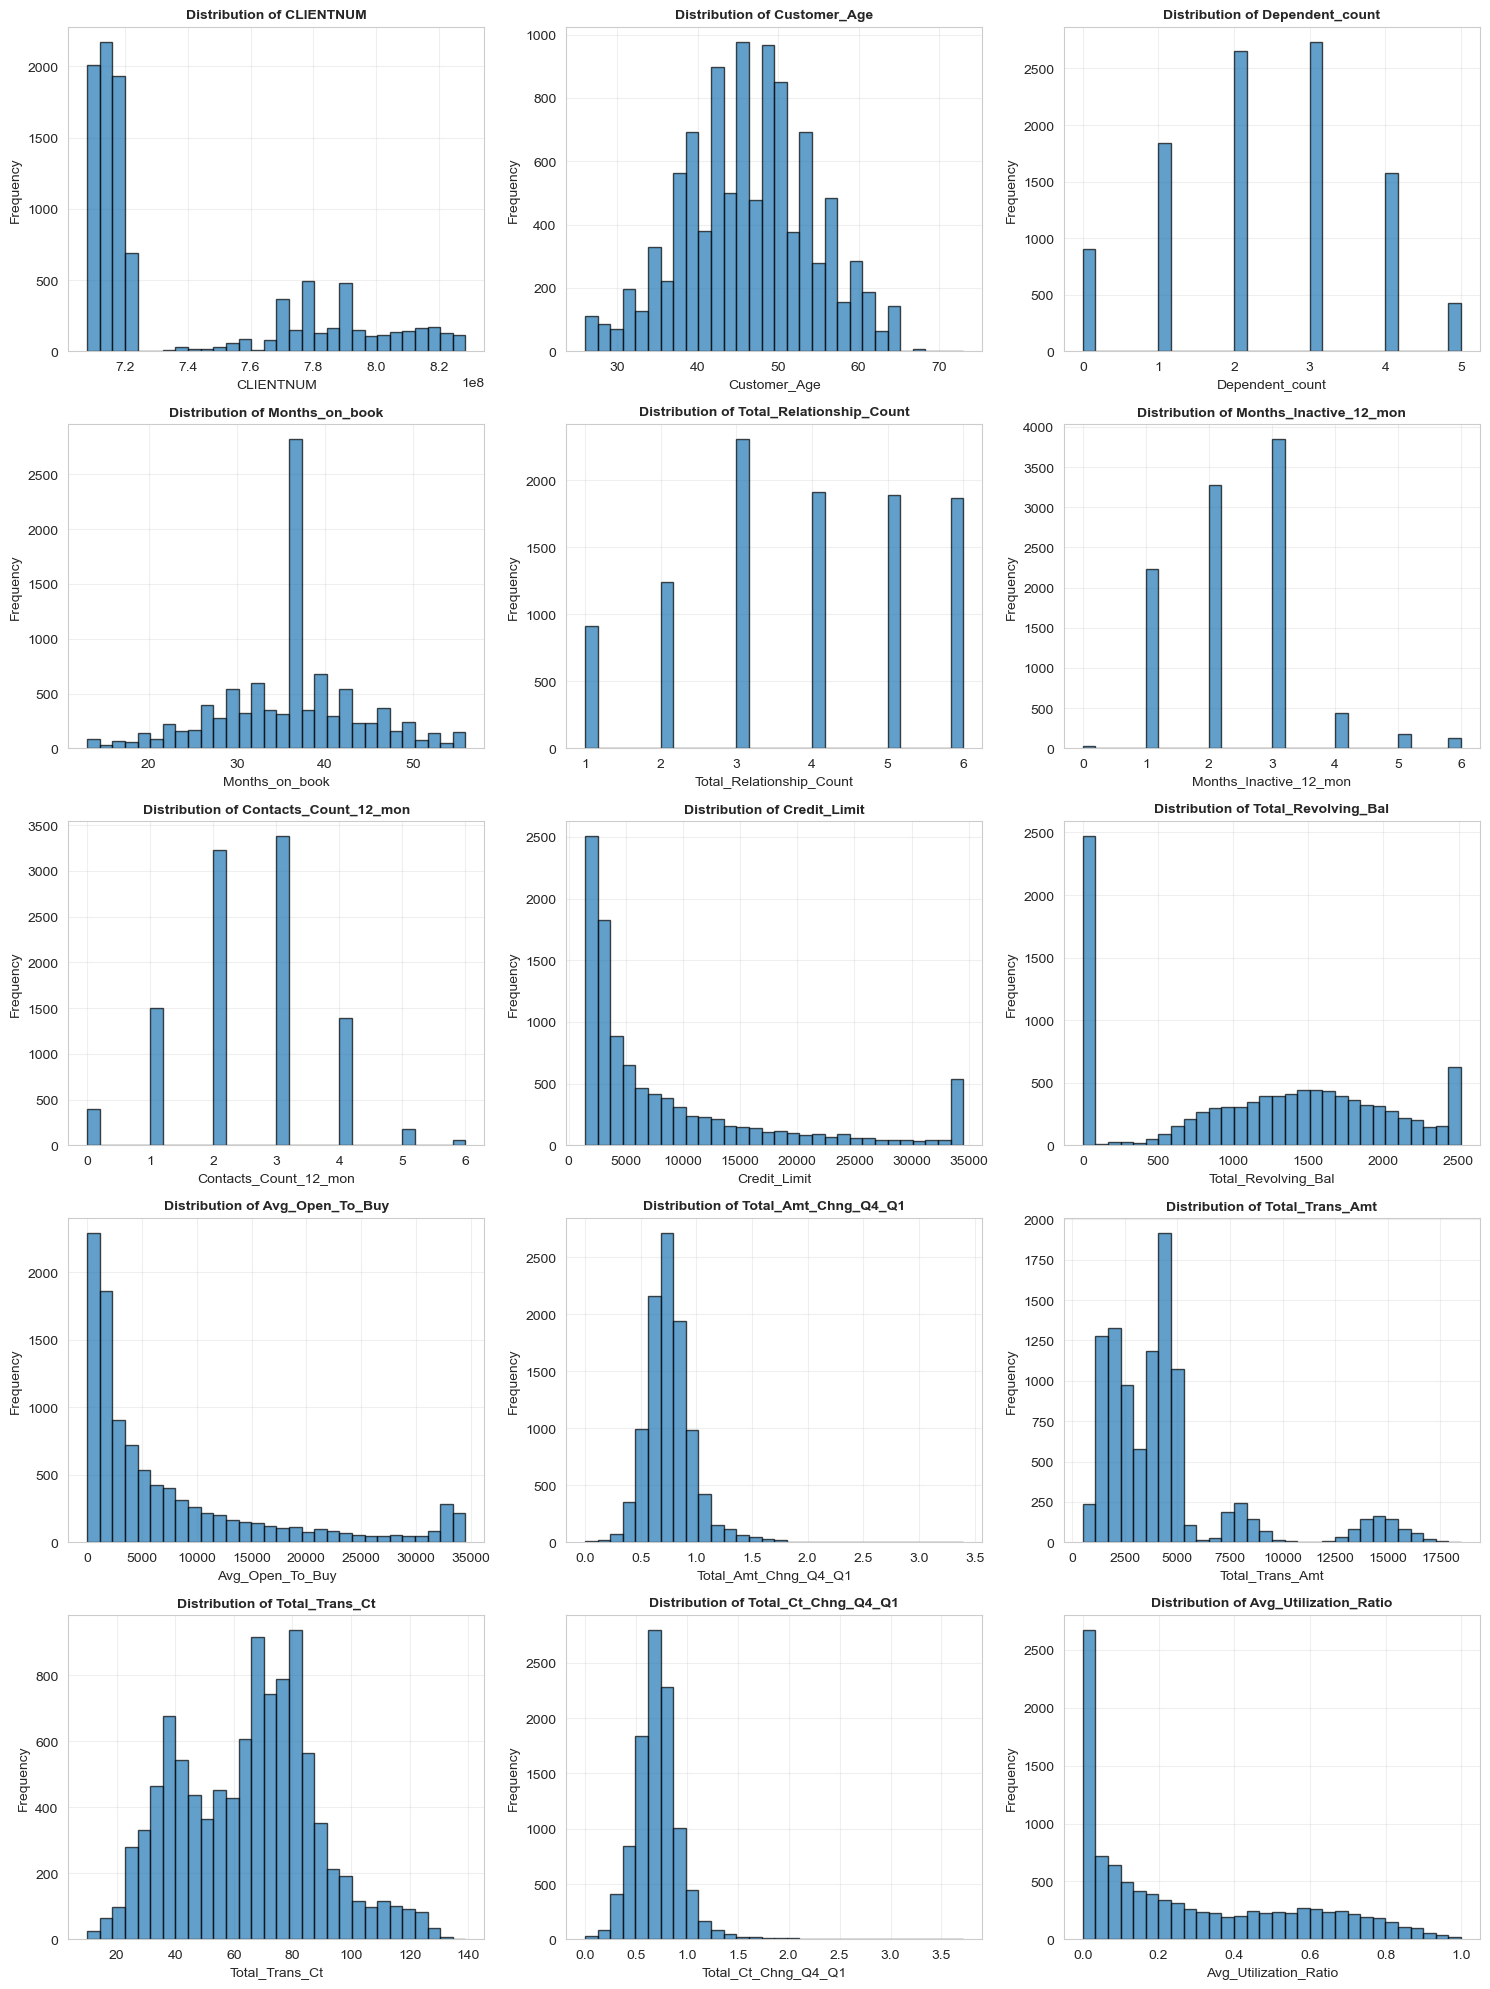

In [11]:
# Visualize distributions of numerical features
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df[col].hist(bins=30, ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 2.4 Correlation Analysis

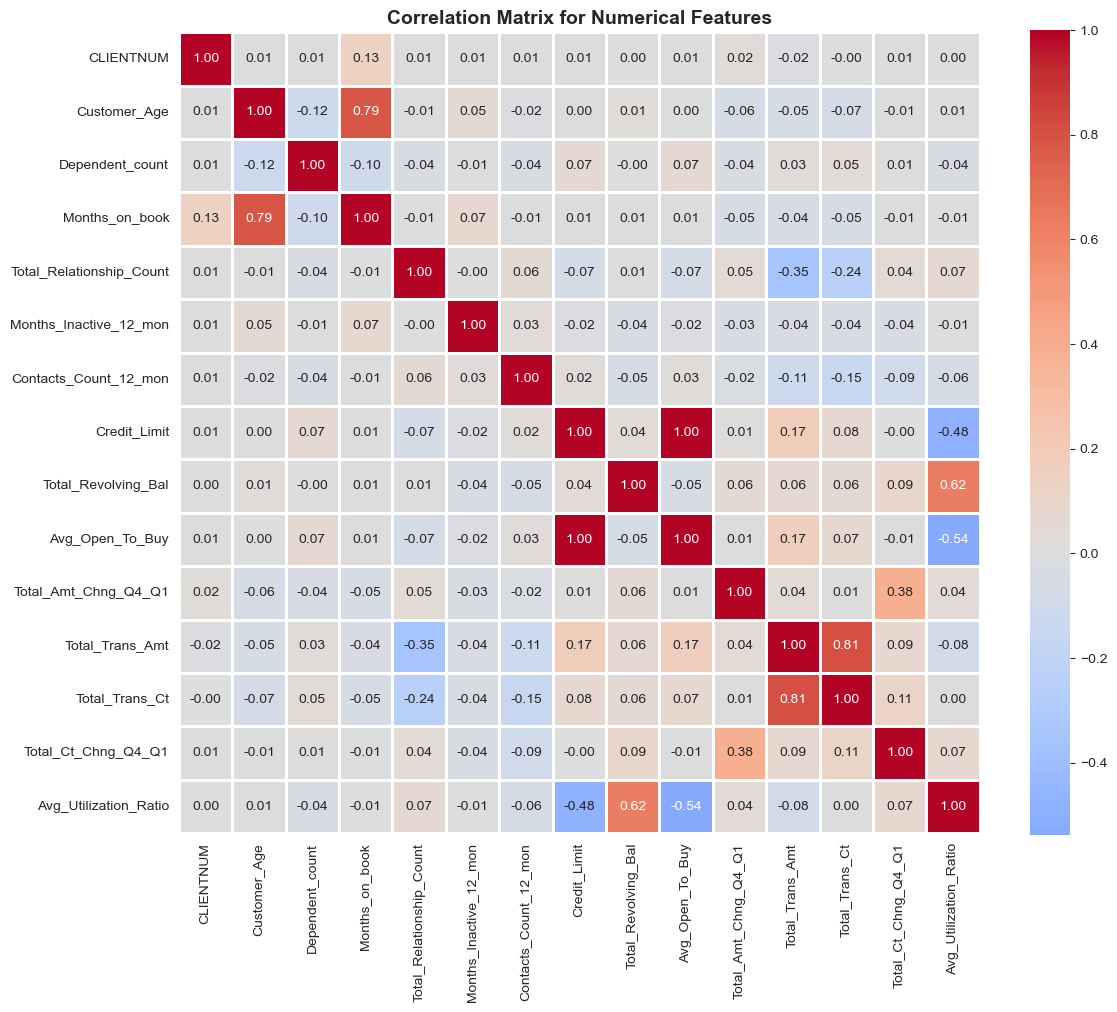

In [12]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix for Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Identify highly correlated features (> 0.8)
print("Highly Correlated Features (|correlation| > 0.8):")


high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr:
    for feat1, feat2, corr in high_corr:
        print(f"{feat1} <-> {feat2}: {corr:.3f}")
else:
    print("No highly correlated features found.")

Highly Correlated Features (|correlation| > 0.8):
Credit_Limit <-> Avg_Open_To_Buy: 0.996
Total_Trans_Amt <-> Total_Trans_Ct: 0.807


### 2.5 Target vs Features Analysis

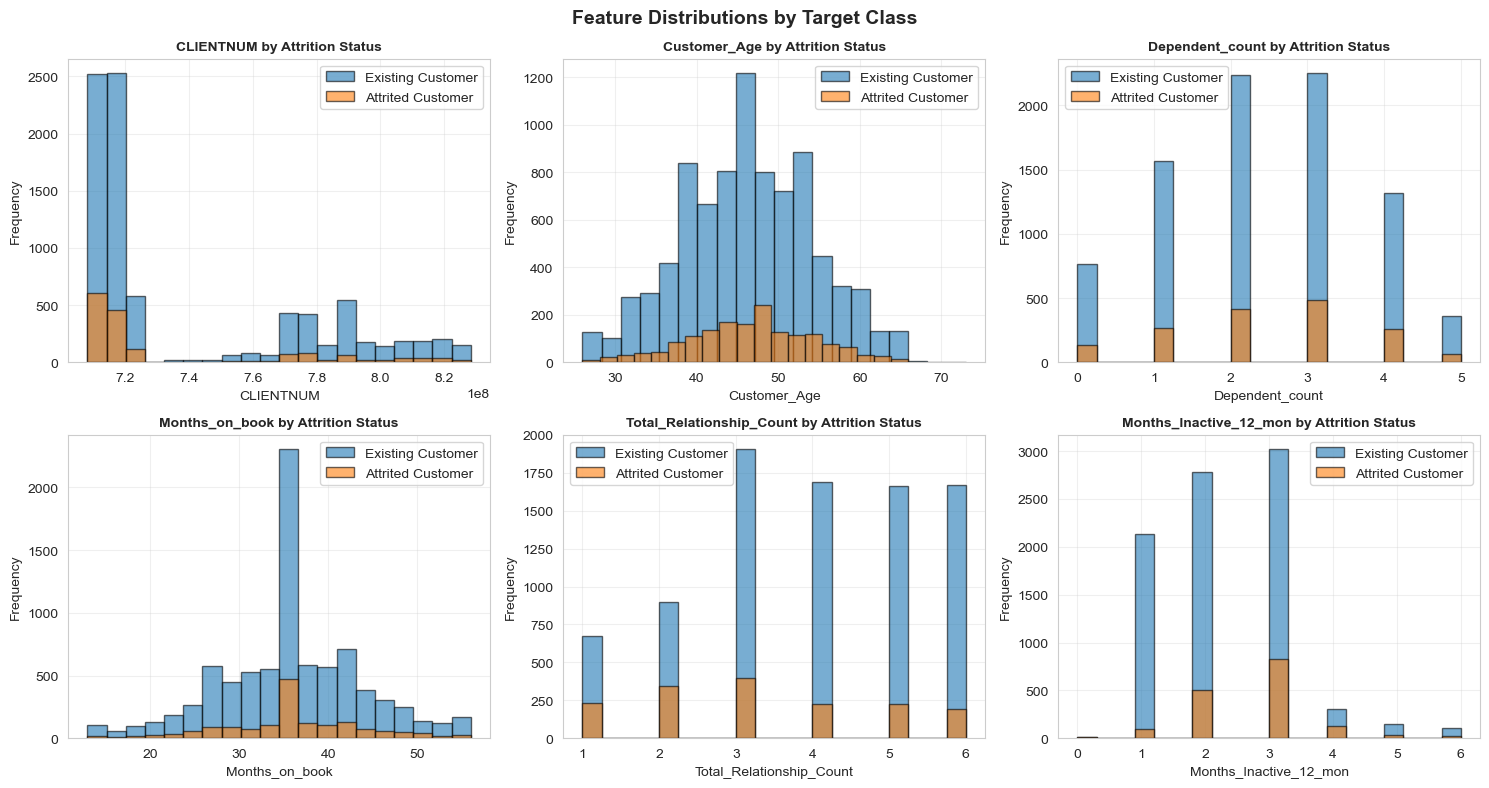

In [14]:
# Compare distributions by target class for key numerical features
key_features = numerical_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    for label in df['Attrition_Flag'].unique():
        data = df[df['Attrition_Flag'] == label][col]
        axes[i].hist(data, bins=20, alpha=0.6, label=label, edgecolor='black')
    
    axes[i].set_title(f'{col} by Attrition Status', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Analysis of Descriptive Statistics

- The target variable shows a class imbalance. About 84% of customers stay with the bank, while 16% churn. This imbalance must be handled during training
- The statistical summary shows that variables such as Total_Trans_Ct and Customer_Age have noticeable variations. Some variables have a wide range, which will require scaling.
- Several features, such as Total_Trans_Ct, display a right-skewed distribution, suggesting a concentration of customers with low transaction counts. A few outliers are visible in transaction-related variables.
- Features such as Total_Trans_Ct and Total_Trans_Amt are strongly correlated, which may indicate redundancy. Feature selection may be required later
- Total_Trans_Ct and Total_Relationship_Count are lower among churned customers. This indicates that less engaged customers are more likely to churn.
- 

## 3.Preprocessing

### 3.1 Target Selection and Basic Checks


In [15]:
# Detect the target column automatically
possible_targets = ["Attrition_Flag", "Churn", "Exited", "churn", "attrition_flag"]
target_col = None
for c in df.columns:
    if c in possible_targets:
        target_col = c
        break

if target_col is None:
    raise ValueError("Target column not found. Please set `target_col` manually.")

# Map target to binary values 
y_raw = df[target_col].copy()
if y_raw.dtype == "object":
    mapping = {
        "Attrited Customer": 1,
        "Existing Customer": 0,
        "Yes": 1, "No": 0,
        "Churned": 1, "Not Churned": 0
    }
    y = y_raw.map(lambda v: mapping.get(v, v)).astype(int)
else:
    y = y_raw.astype(int)

X = df.drop(columns=[target_col]).copy()

print(f"Target column: {target_col}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


Target column: Attrition_Flag
X shape: (10127, 20), y shape: (10127,)


### 3.2 Drop Irrelevant or Constant Columns


In [16]:
candidate_id_cols = [c for c in X.columns if "id" in c.lower() or "uuid" in c.lower()]
constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]

cols_to_drop = sorted(set(candidate_id_cols + constant_cols))
if cols_to_drop:
    X.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped columns: {cols_to_drop if cols_to_drop else 'None'}")

# Remove duplicates if any
before = len(X)
X = X.drop_duplicates()
y = y.loc[X.index]
after = len(X)
print(f"Removed duplicates: {before - after}")


Dropped columns: None
Removed duplicates: 0


### 3.3 Identify Numeric and Categorical Features


In [17]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f" Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")


 Numeric features: 15
Categorical features: 5


### 3.4 Train/Test Split with Stratification


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

def describe_imbalance(y_vec, label="[y]"):
    counts = y_vec.value_counts(dropna=False)
    print(f"[IMBALANCE] {label}:")
    print(counts.to_string())
    if len(counts) == 2:
        minority, majority = counts.min(), counts.max()
        if minority > 0:
            ratio = round(majority/minority, 1)
            print(f" -> ratio ≈ 1:{ratio}")
        else:
            print(" One class has zero samples.")
    print()

describe_imbalance(y, "Full dataset")
describe_imbalance(y_train, "Train")
describe_imbalance(y_test, "Test")


[IMBALANCE] Full dataset:
Attrition_Flag
0    8500
1    1627
 -> ratio ≈ 1:5.2

[IMBALANCE] Train:
Attrition_Flag
0    6799
1    1302
 -> ratio ≈ 1:5.2

[IMBALANCE] Test:
Attrition_Flag
0    1701
1     325
 -> ratio ≈ 1:5.2



### 3.5 Preprocessing Pipelines (Imputation, Encoding, Scaling)


In [19]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"X_train processed shape: {X_train_proc.shape}")
print(f"X_test processed shape: {X_test_proc.shape}")


X_train processed shape: (8101, 38)
X_test processed shape: (2026, 38)


In [29]:
# alias pour compatibilité avec le reste du code
X_train_scaled = X_train_proc
X_test_scaled  = X_test_proc


### 3.7 Pipelines with Rebalancing (for the next steps)


In [20]:
from sklearn.linear_model import LogisticRegression

# Baseline pipeline (no resampling)
baseline_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Oversampling pipeline
oversample_clf = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("ros", RandomOverSampler(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# SMOTE pipeline
smote_clf = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

print(" Pipelines ready: baseline_clf, oversample_clf, smote_clf")


 Pipelines ready: baseline_clf, oversample_clf, smote_clf


### 3.7 Preprocessing Analysis

The dataset contains 10,127 observations and 20 features after removing the target column.  
No irrelevant or constant columns were found, and no duplicate rows were removed.  

We identified:
- 15 numerical features
- 5 categorical features

After splitting the datas
let (80% train / 20% test) using **stratified sampling**, the churn class remained imbalanced with a ratio of approximately **1:5.2** between churned and non-churned customers in both train and test sets.  

The preprocessing pipeline applied:
- Median imputation for numerical features
- Most frequent imputation for categorical features
- Standard scaling for numerical data
- One-hot encoding for categorical variables

After preprocessing:
- `X_train` shape: (8101, 38)  
- `X_test` shape: (2026, 38)

These transformations ensure that the data is clean, well-structured, and ready for model training in the next steps.


## 4. Problem Formalization

This is a **binary classification problem**: predicting if a bank customer will churn (1) or stay (0). The main challenge is **class imbalance**, so we will pay more attention to metrics like **recall** and **F1-score** rather than accuracy.  

**Goal:** Identify customers at risk of leaving the bank to help the company act early.  
**Constraints:**  
- Imbalanced classes (majority stay, minority churn)  
- Minimize false negatives (catch as many churners as possible)  
- Keep the model interpretable

**Modeling plan:**  
- Start with Logistic Regression (baseline)  
- Then try Random Forest and XGBoost  
- Compare models with and without SMOTE/oversampling  

**Metrics:**  
- Recall, Precision, F1-score, ROC AUC, Confusion Matrix  
- Focus on **recall** because missing a churner is more costly than a false alarm.



###  5.1 Model Selection

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_proc, y_train)

y_pred_baseline = baseline_model.predict(X_test_proc)
y_proba_baseline = baseline_model.predict_proba(X_test_proc)[:, 1]


###  5.2 Evaluation Metrics


In [22]:
# Evaluate the model with Recall, Precision, F1, ROC AUC and Confusion Matrix
print("Classification Report (Baseline) ")
print(classification_report(y_test, y_pred_baseline, target_names=["No Churn", "Churn"]))

roc_auc = roc_auc_score(y_test, y_proba_baseline)
print(f"ROC AUC Score: {roc_auc:.4f}")

print("\n Confusion Matrix")
print(confusion_matrix(y_test, y_pred_baseline))


Classification Report (Baseline) 
              precision    recall  f1-score   support

    No Churn       0.92      0.97      0.95      1701
       Churn       0.79      0.56      0.65       325

    accuracy                           0.91      2026
   macro avg       0.85      0.77      0.80      2026
weighted avg       0.90      0.91      0.90      2026

ROC AUC Score: 0.9179

 Confusion Matrix
[[1652   49]
 [ 143  182]]


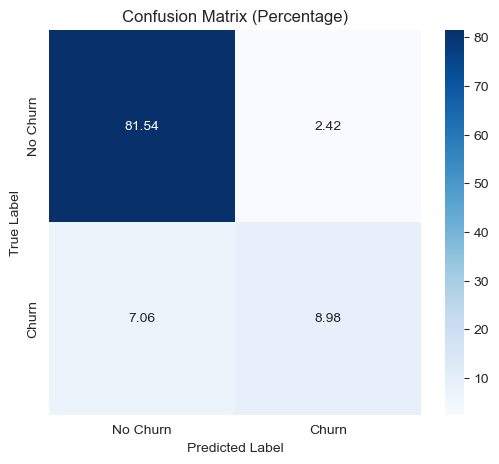

Confusion Matrix (Raw counts):
[[1652   49]
 [ 143  182]]


In [23]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
cm_percent = cm / cm.sum() * 100  # convert to percentages

# Define labels
labels = ["No Churn", "Churn"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Confusion Matrix (Raw counts):")
print(cm)


In [24]:

feature_names_num = numeric_features
feature_names_cat = list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features))
all_features = feature_names_num + feature_names_cat

coef_df = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": baseline_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df.head(10)


,Feature,Coefficient
11,Total_Trans_Amt,1.552099
6,Contacts_Count_12_mon,0.577668
5,Months_Inactive_12_mon,0.520259
28,Income_Category_$120K +,0.357225
2,Dependent_count,0.234615
35,Card_Category_Gold,0.214265
18,Education_Level_Doctorate,0.058052
21,Education_Level_Post-Graduate,0.056695
31,Income_Category_$80K - $120K,0.042601
36,Card_Category_Platinum,0.040438


## 5.6 Baseline Model Analysis

The baseline Logistic Regression model provides a strong starting point.  
- The **ROC AUC score (0.918)** indicates good separation between churners and non-churners.  
- The **accuracy is 91 %**, mainly driven by the majority class.  
- Recall for churners (0.56) is lower, meaning the model misses some customers who actually churn.  
- The confusion matrix shows that most non-churners are correctly predicted, while a significant portion of churners are misclassified.  

Top features influencing churn include:
- `Total_Trans_Amt` (most impactful),
- `Contacts_Count_12_mon`,
- `Months_Inactive_12_mon`,
- High income categories and card type.

These results confirm that the model captures relevant signals but is affected by class imbalance.  


---
# LAB 6 - Part II: Advanced Model Optimization
---

In this section, we apply:
1. **Grid Search** to optimize baseline models
2. **Ensemble Methods** (Voting, Bagging, Stacking)
3. **Model Comparison** and performance analysis

## 6. Grid Search Optimization

### 6.1 Import Additional Libraries

In [26]:
pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.6/72.0 MB 8.4 MB/s eta 0:00:09
   - -------------------------------------- 2.9/72.0 MB 7.0 MB/s eta 0:00:10
   -- ------------------------------------- 4.5/72.0 MB 7.2 MB/s eta 0:00:10
   --- ------------------------------------ 6.3/72.0 MB 7.5 MB/s eta 0:00:09
   ---- ----------------------------------- 7.9/72.0 MB 7.6 MB/s eta 0:00:09
   ----- ---------------------------------- 9.4/72.0 MB 7.5 MB/s eta 0:00:09
   ------ --------------------------------- 11.0/72.0 MB 7.6 MB/s eta 0:00:09
   ------ --------------------------------- 12.3/72.0 MB 7.4 MB/s eta 0:00:09
   ------- -------------------------------- 13.9/72.0 MB 7.4 MB/s eta 0:00:08
   -------- ------------------------------- 15.7/72.0 MB 7.6 MB/s eta 0:00:08
   --------- ------------------------------ 17.3/72.0 MB 7.6 MB/s eta 0:00:08
   ---------- ----------------------------- 18.6/72.0 MB 7.5 MB/s eta 0:00:08


In [27]:
# Grid Search and Ensemble Methods
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    BaggingClassifier,
    StackingClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import time

print("Additional libraries imported for Grid Search and Ensemble Learning")

Additional libraries imported for Grid Search and Ensemble Learning


### 6.2 Grid Search for Logistic Regression

Optimize the baseline Logistic Regression model using Grid Search.

In [30]:
# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

# Create Logistic Regression model
lr_model = LogisticRegression(random_state=42, class_weight='balanced')

# Grid Search with Cross Validation
print("Starting Grid Search for Logistic Regression")
print("...\n")

start_time = time.time()

grid_search_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1', 
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid_search_lr.fit(X_train_scaled, y_train)

end_time = time.time()

print(f"\n Grid Search completed in {end_time - start_time:.2f} seconds")
print(f"\nBest Parameters: {grid_search_lr.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search_lr.best_score_:.3f}")

Starting Grid Search for Logistic Regression
...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Grid Search completed in 3.39 seconds

Best Parameters: {'C': 1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation F1 Score: 0.644


In [31]:
# Evaluate optimized model on test set
best_lr = grid_search_lr.best_estimator_
y_pred_lr_optimized = best_lr.predict(X_test_scaled)
y_pred_proba_lr_optimized = best_lr.predict_proba(X_test_scaled)[:, 1]

print("Optimized Logistic Regression - Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr_optimized):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_optimized):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr_optimized):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr_optimized):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_lr_optimized):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_optimized, 
                          target_names=['Not Churned', 'Churned']))

Optimized Logistic Regression - Test Set Performance:
Accuracy:  0.862
Precision: 0.546
Recall:    0.818
F1-Score:  0.655
ROC AUC:   0.922

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.96      0.87      0.91      1701
     Churned       0.55      0.82      0.66       325

    accuracy                           0.86      2026
   macro avg       0.75      0.84      0.78      2026
weighted avg       0.90      0.86      0.87      2026



### 6.3 Grid Search for Decision Tree

Optimize a Decision Tree classifier.

In [32]:
# Define parameter grid for Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'class_weight': ['balanced', None]
}

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

print("Starting Grid Search for Decision Tree")
print("...\n")

start_time = time.time()

grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train_scaled, y_train)

end_time = time.time()

print(f"\n Grid Search completed in {end_time - start_time:.2f} seconds")
print(f"\nBest Parameters: {grid_search_dt.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search_dt.best_score_:.3f}")

Starting Grid Search for Decision Tree
...

Fitting 5 folds for each of 320 candidates, totalling 1600 fits

 Grid Search completed in 6.37 seconds

Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Cross-Validation F1 Score: 0.825


In [33]:
# Evaluate optimized Decision Tree
best_dt = grid_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)
y_pred_proba_dt = best_dt.predict_proba(X_test_scaled)[:, 1]

print("Optimized Decision Tree :")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_dt):.3f}")

Optimized Decision Tree :
Accuracy:  0.948
Precision: 0.869
Recall:    0.797
F1-Score:  0.831
ROC AUC:   0.917


### 6.4 Grid Search for Random Forest

Random Forest is an ensemble method that combines multiple decision trees.

In [34]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Create Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

print("Starting Grid Search for Random Forest")
print("...\n")

start_time = time.time()

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_scaled, y_train)

end_time = time.time()

print(f"\n Grid Search completed in {end_time - start_time:.2f} seconds")
print(f"\nBest Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search_rf.best_score_:.3f}")

Starting Grid Search for Random Forest
...

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

 Grid Search completed in 110.51 seconds

Best Parameters: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation F1 Score: 0.866


In [35]:
# Evaluate optimized Random Forest
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print("Optimized Random Forest")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.3f}")

Optimized Random Forest
Accuracy:  0.948
Precision: 0.844
Recall:    0.831
F1-Score:  0.837
ROC AUC:   0.982


---
## 7. Ensemble Methods

### 7.1 Voting Classifier

Combines predictions from multiple models using voting (soft or hard).

In [36]:
# Create Voting Classifier with optimized models
voting_clf = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('dt', best_dt),
        ('rf', best_rf)
    ],
    voting='soft' 
)

print("...")
start_time = time.time()

voting_clf.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds")

...
Training completed in 0.41 seconds


In [37]:
# Evaluate Voting Classifier
y_pred_voting = voting_clf.predict(X_test_scaled)
y_pred_proba_voting = voting_clf.predict_proba(X_test_scaled)[:, 1]

print("Voting Classifier ")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_voting):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_voting):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_voting):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_voting):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_voting):.3f}")

Voting Classifier 
Accuracy:  0.955
Precision: 0.885
Recall:    0.828
F1-Score:  0.855
ROC AUC:   0.977


### 7.2 Bagging Classifier

Creates multiple versions of a predictor by training on random subsets of data.

In [38]:
# Bagging with Decision Tree
bagging_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced'),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training Bagging Classifier ")
start_time = time.time()

bagging_dt.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds")

Training Bagging Classifier (Decision Tree)
Training completed in 0.30 seconds


In [39]:
# Evaluate Bagging Classifier
y_pred_bagging = bagging_dt.predict(X_test_scaled)
y_pred_proba_bagging = bagging_dt.predict_proba(X_test_scaled)[:, 1]

print("Bagging Classifier")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_bagging):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_bagging):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_bagging):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_bagging):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_bagging):.3f}")

Bagging Classifier
Accuracy:  0.955
Precision: 0.887
Recall:    0.825
F1-Score:  0.855
ROC AUC:   0.985


### 7.3 Stacking Classifier

Uses predictions from base models as features for a meta-model.

In [40]:
# Define base models for stacking
base_models = [
    ('lr', LogisticRegression(C=best_lr.C, solver=best_lr.solver, random_state=42, class_weight='balanced')),
    ('dt', best_dt),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'))
]

# Meta-model
meta_model = LogisticRegression(random_state=42, class_weight='balanced')

# Create Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

print("Training Stacking Classifier")
print("...\n")

start_time = time.time()

stacking_clf.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds")

Training Stacking Classifier
...

Training completed in 2.32 seconds


In [41]:
# Evaluate Stacking Classifier
y_pred_stacking = stacking_clf.predict(X_test_scaled)
y_pred_proba_stacking = stacking_clf.predict_proba(X_test_scaled)[:, 1]

print("Stacking Classifier")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_stacking):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_stacking):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_stacking):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_stacking):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba_stacking):.3f}")

Stacking Classifier
Accuracy:  0.947
Precision: 0.786
Recall:    0.917
F1-Score:  0.847
ROC AUC:   0.982


In [43]:
#  Baseline Logistic Regression: predictions & probabilités

from sklearn.linear_model import LogisticRegression
import numpy as np


def proba_positif(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        z = model.decision_function(X)
        
        return 1.0 / (1.0 + np.exp(-z))
    else:
        raise AttributeError("Le modèle ne fournit ni predict_proba ni decision_function.")


try:
    baseline_lr
except NameError:
    baseline_lr = LogisticRegression(
        random_state=42, class_weight="balanced", solver="liblinear", max_iter=500
    )
    baseline_lr.fit(X_train_scaled, y_train)


y_pred_baseline = baseline_lr.predict(X_test_scaled)
y_pred_proba_baseline = proba_positif(baseline_lr, X_test_scaled)


---
## 8. Model Comparison and Analysis

### 8.1 Performance Comparison Table

In [44]:
# Create comprehensive comparison table
models_comparison = pd.DataFrame({
    'Model': [
        'Baseline LR',
        'Optimized LR',
        'Optimized DT',
        'Optimized RF',
        'Voting',
        'Bagging',
        'Stacking'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_lr_optimized),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_voting),
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_stacking)
    ],
    'Precision': [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_lr_optimized),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_voting),
        precision_score(y_test, y_pred_bagging),
        precision_score(y_test, y_pred_stacking)
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_lr_optimized),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_voting),
        recall_score(y_test, y_pred_bagging),
        recall_score(y_test, y_pred_stacking)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_lr_optimized),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_voting),
        f1_score(y_test, y_pred_bagging),
        f1_score(y_test, y_pred_stacking)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_pred_proba_baseline),
        roc_auc_score(y_test, y_pred_proba_lr_optimized),
        roc_auc_score(y_test, y_pred_proba_dt),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_voting),
        roc_auc_score(y_test, y_pred_proba_bagging),
        roc_auc_score(y_test, y_pred_proba_stacking)
    ]
})

# Round values for readability
models_comparison = models_comparison.round(3)

# Highlight best scores
print("Model Performance Comparison:")
display(models_comparison)

print("\nBest Models:")
print(f"  Highest Accuracy:  {models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Model']}")
print(f"  Highest Precision: {models_comparison.loc[models_comparison['Precision'].idxmax(), 'Model']}")
print(f"  Highest Recall:    {models_comparison.loc[models_comparison['Recall'].idxmax(), 'Model']}")
print(f"  Highest F1-Score:  {models_comparison.loc[models_comparison['F1-Score'].idxmax(), 'Model']}")
print(f"  Highest ROC AUC:   {models_comparison.loc[models_comparison['ROC AUC'].idxmax(), 'Model']}")

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Baseline LR,0.862,0.546,0.818,0.655,0.922
1,Optimized LR,0.862,0.546,0.818,0.655,0.922
2,Optimized DT,0.948,0.869,0.797,0.831,0.917
3,Optimized RF,0.948,0.844,0.831,0.837,0.982
4,Voting,0.955,0.885,0.828,0.855,0.977
5,Bagging,0.955,0.887,0.825,0.855,0.985
6,Stacking,0.947,0.786,0.917,0.847,0.982



Best Models:
  Highest Accuracy:  Voting
  Highest Precision: Bagging
  Highest Recall:    Stacking
  Highest F1-Score:  Voting
  Highest ROC AUC:   Bagging


### 8.2 Visual Comparison of Models

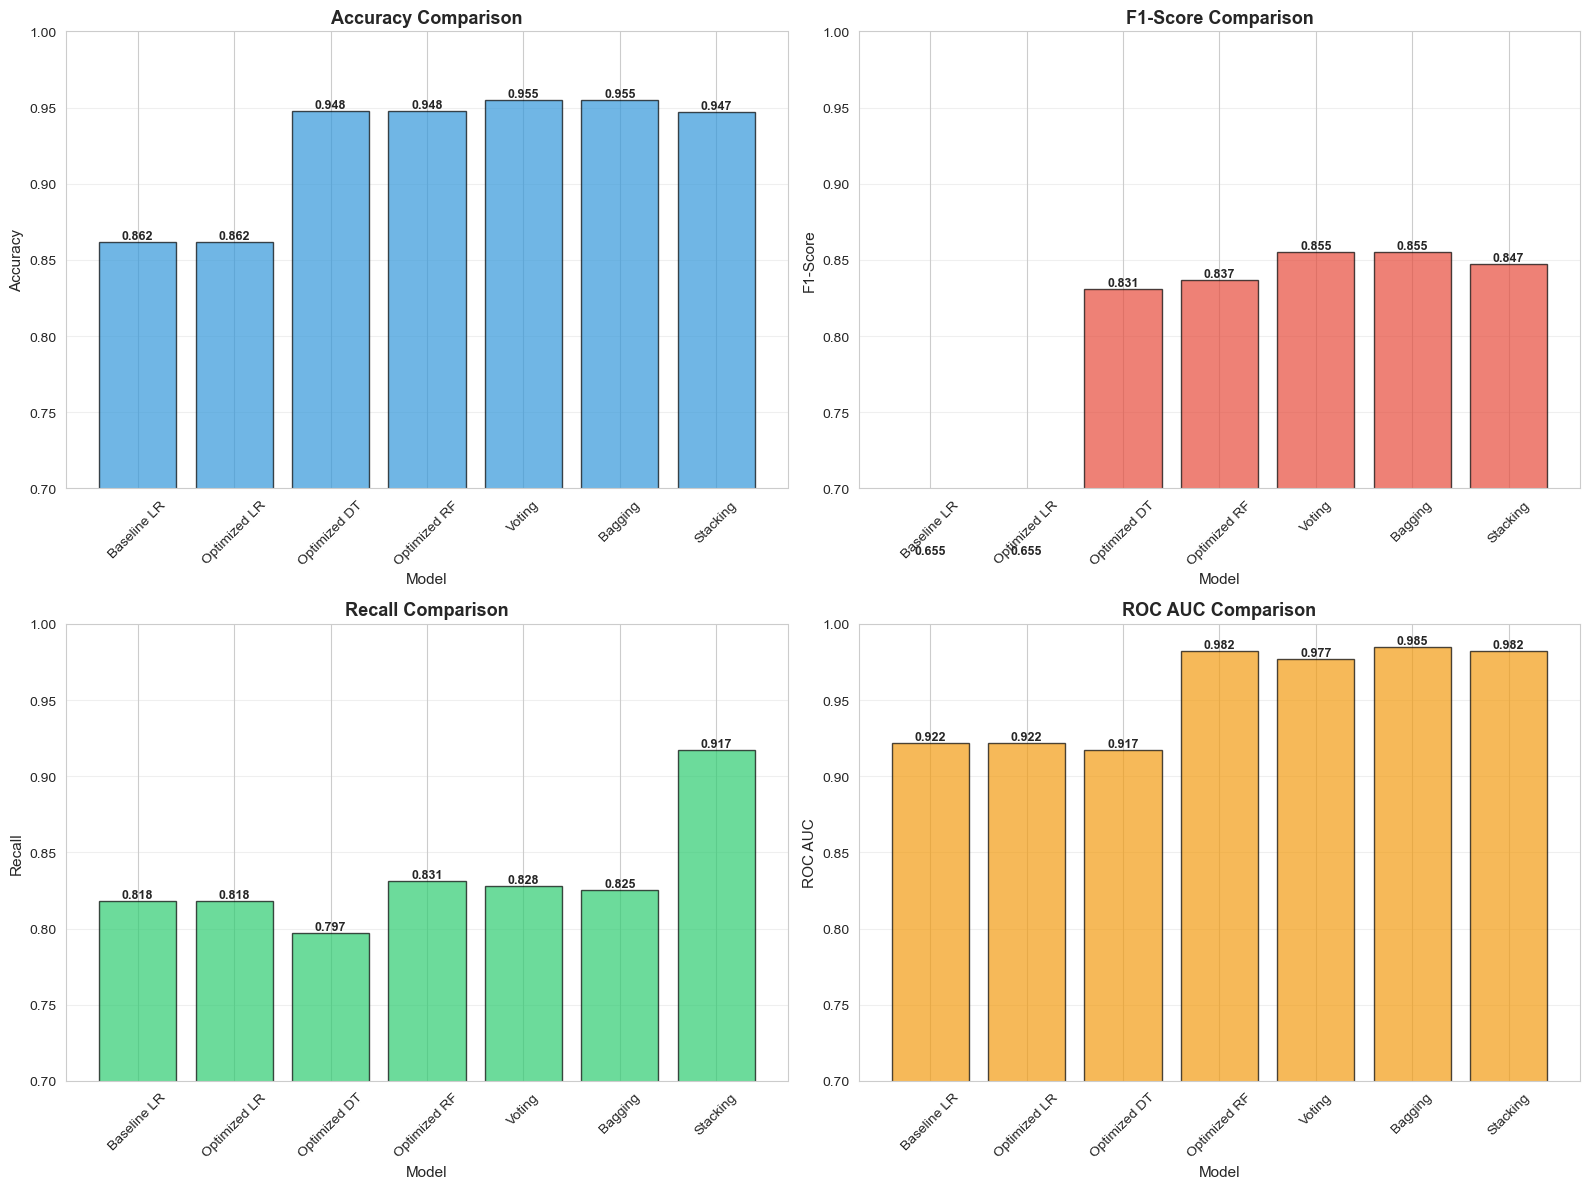

In [45]:
# Bar plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'F1-Score', 'Recall', 'ROC AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (ax, metric, color) in enumerate(zip(axes.flatten(), metrics, colors)):
    bars = ax.bar(models_comparison['Model'], models_comparison[metric], 
                   color=color, alpha=0.7, edgecolor='black')
    
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim([0.7, 1.0])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 8.3 ROC Curves Comparison

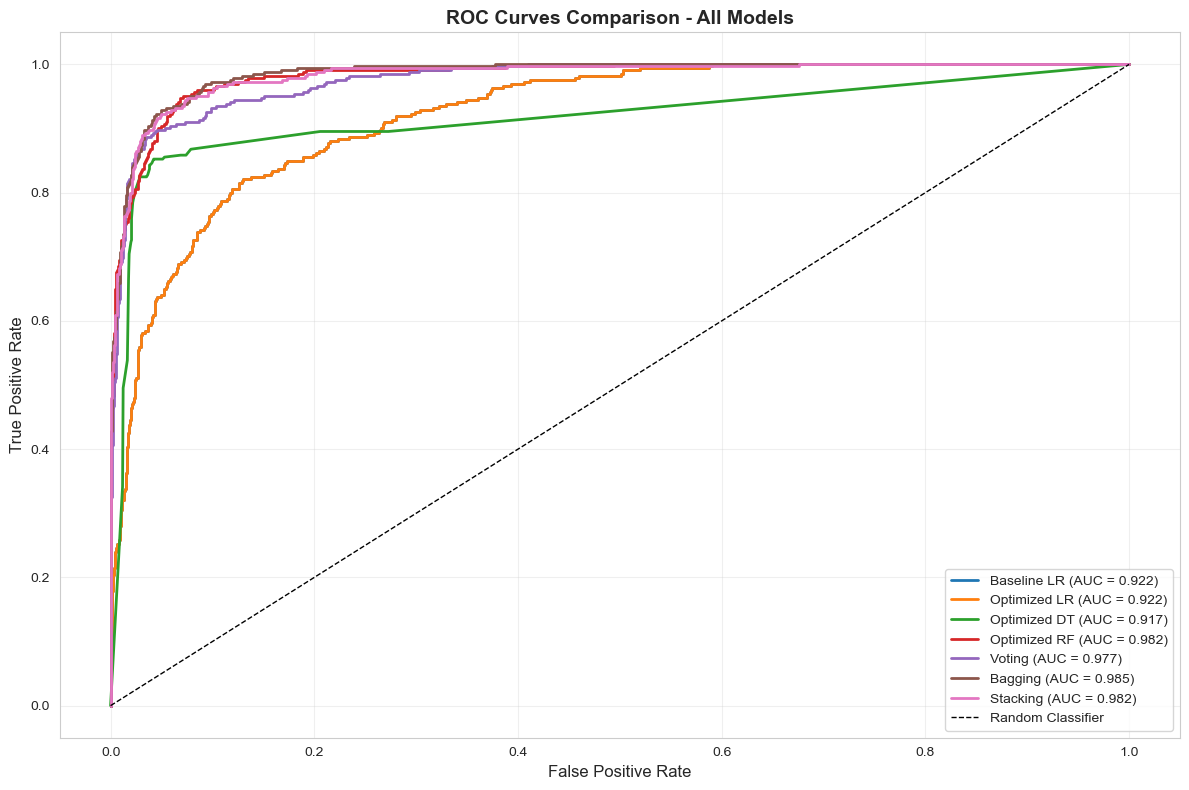

In [46]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

# Calculate ROC curves
models_roc = [
    ('Baseline LR', y_pred_proba_baseline),
    ('Optimized LR', y_pred_proba_lr_optimized),
    ('Optimized DT', y_pred_proba_dt),
    ('Optimized RF', y_pred_proba_rf),
    ('Voting', y_pred_proba_voting),
    ('Bagging', y_pred_proba_bagging),
    ('Stacking', y_pred_proba_stacking)
]

for name, y_proba in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 Confusion Matrices Comparison

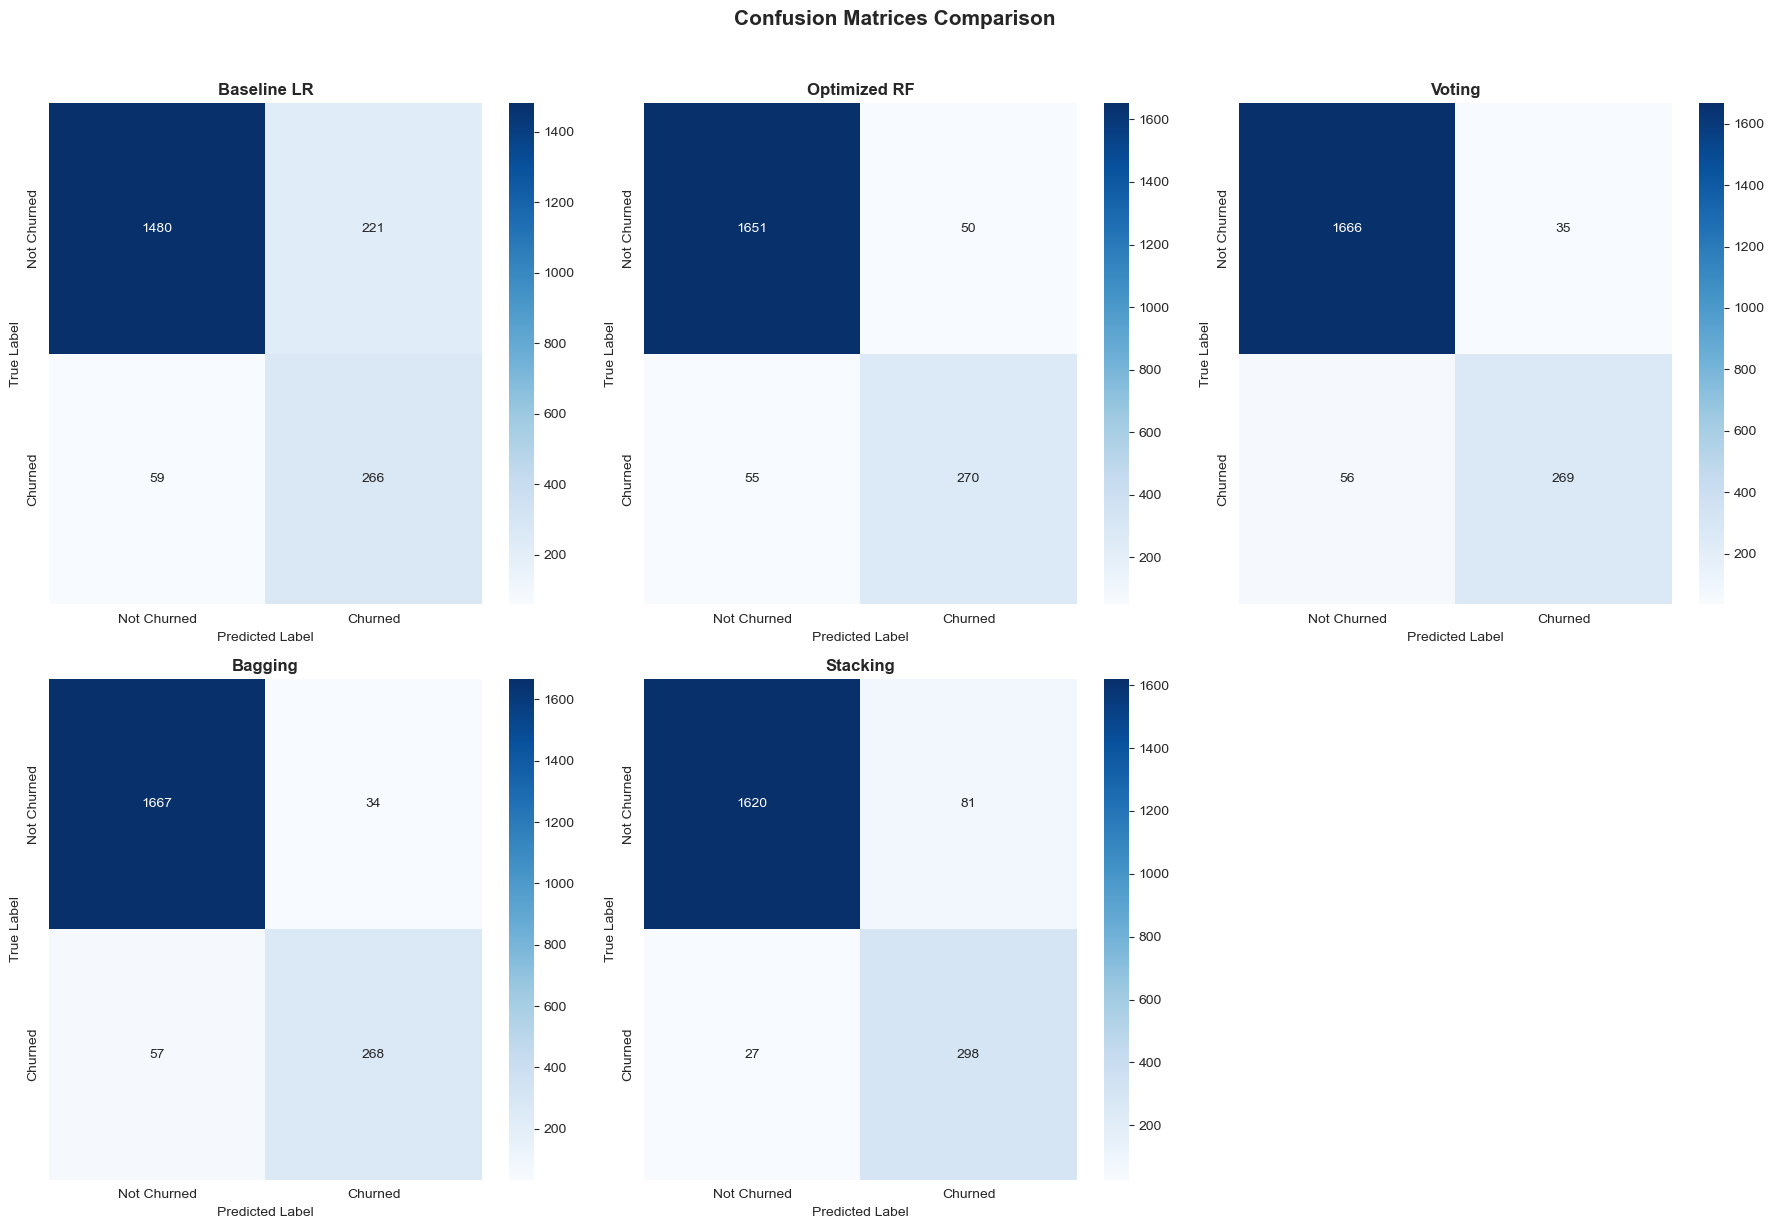

In [47]:
# Plot confusion matrices for key models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

models_cm = [
    ('Baseline LR', y_pred_baseline),
    ('Optimized RF', y_pred_rf),
    ('Voting', y_pred_voting),
    ('Bagging', y_pred_bagging),
    ('Stacking', y_pred_stacking)
]

for idx, (ax, (name, y_pred)) in enumerate(zip(axes.flatten(), models_cm)):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Churned', 'Churned'],
                yticklabels=['Not Churned', 'Churned'])
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

if len(models_cm) < len(axes.flatten()):
    axes.flatten()[-1].axis('off')

plt.suptitle('Confusion Matrices Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.5 Feature Importance (Random Forest)

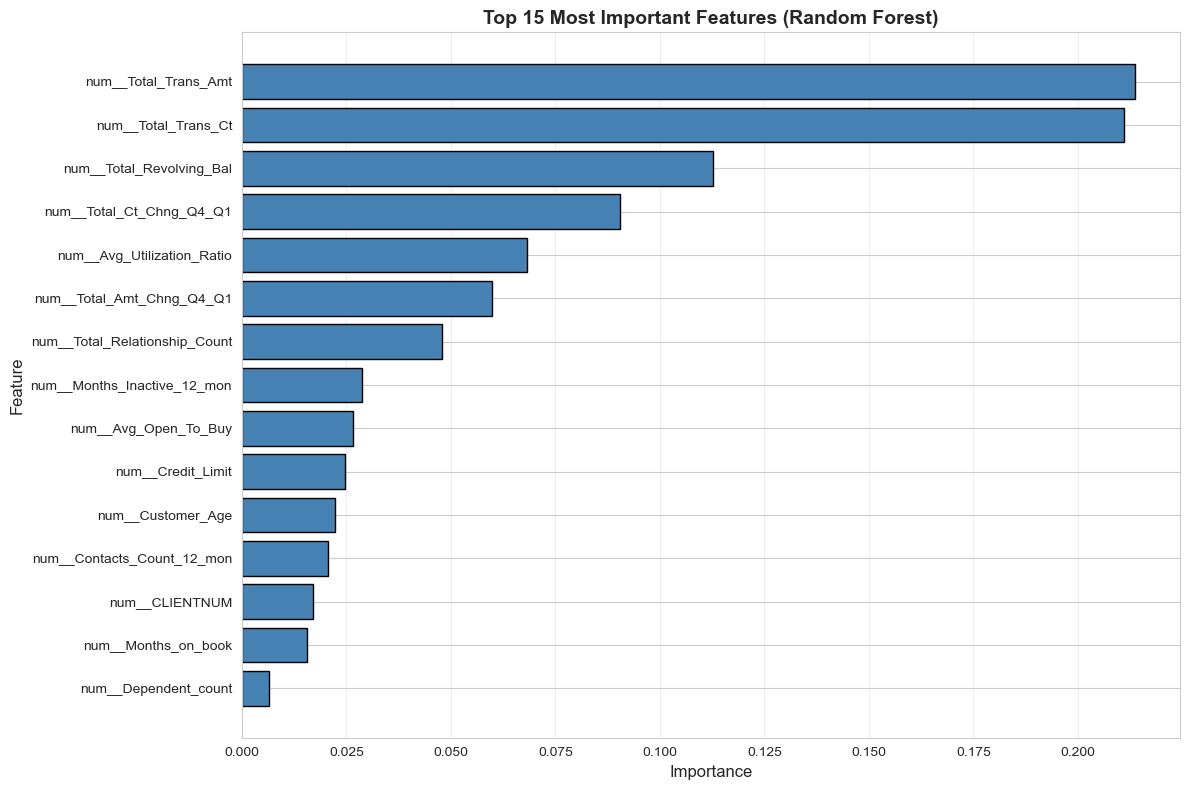


Top 10 Most Important Features:
                          Feature  Importance
11           num__Total_Trans_Amt    0.213712
12            num__Total_Trans_Ct    0.210995
8        num__Total_Revolving_Bal    0.112602
13       num__Total_Ct_Chng_Q4_Q1    0.090420
14     num__Avg_Utilization_Ratio    0.068112
10      num__Total_Amt_Chng_Q4_Q1    0.059759
4   num__Total_Relationship_Count    0.047969
5     num__Months_Inactive_12_mon    0.028777
9            num__Avg_Open_To_Buy    0.026507
7               num__Credit_Limit    0.024596


In [49]:
# --- Get feature importance from Random Forest (fixed version) ---

try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
   
    num_feats = numeric_features          
    cat_feats = categorical_features       

    ohe = preprocessor.named_transformers_['cat']
    if hasattr(ohe, 'named_steps'):  # si c’est un pipeline
        ohe = ohe.named_steps['onehot']

    cat_out = ohe.get_feature_names_out(cat_feats)
    feature_names = np.r_[num_feats, cat_out]


feature_importance = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_rf.feature_importances_
    })
    .sort_values(by='Importance', ascending=False)
)

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1],
         color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))


---
## 9. Final Analysis and Conclusions

### 9.1 Model Selection Criteria

In [51]:
# Create extended comparison with interpretability and complexity
extended_comparison = pd.DataFrame({
    'Model': models_comparison['Model'],
    'F1-Score': models_comparison['F1-Score'],
    'ROC AUC': models_comparison['ROC AUC'],
    'Interpretability': ['High', 'High', 'Medium', 'Low', 'Low', 'Low', 'Very Low'],
    'Training Time': ['Fast', 'Fast', 'Fast', 'Medium', 'Medium', 'Slow', 'Slow'],
    'Inference Speed': ['Fast', 'Fast', 'Fast', 'Medium', 'Slow', 'Slow', 'Slow']
})

print("Extended Model Comparison:")
display(extended_comparison)

print("RECOMMENDATION:")

best_f1_model = models_comparison.loc[models_comparison['F1-Score'].idxmax()]
print(f"\nBest Overall Model: {best_f1_model['Model']}")
print(f"  - F1-Score: {best_f1_model['F1-Score']:.3f}")
print(f"  - ROC AUC: {best_f1_model['ROC AUC']:.3f}")
print(f"  - Recall: {best_f1_model['Recall']:.3f}")
print(f"  - Precision: {best_f1_model['Precision']:.3f}")

Extended Model Comparison:


,Model,F1-Score,ROC AUC,Interpretability,Training Time,Inference Speed
0,Baseline LR,0.655,0.922,High,Fast,Fast
1,Optimized LR,0.655,0.922,High,Fast,Fast
2,Optimized DT,0.831,0.917,Medium,Fast,Fast
3,Optimized RF,0.837,0.982,Low,Medium,Medium
4,Voting,0.855,0.977,Low,Medium,Slow
5,Bagging,0.855,0.985,Low,Slow,Slow
6,Stacking,0.847,0.982,Very Low,Slow,Slow


RECOMMENDATION:

Best Overall Model: Voting
  - F1-Score: 0.855
  - ROC AUC: 0.977
  - Recall: 0.828
  - Precision: 0.885


### 9.2 Key Findings and Insights

## Summary of Results

We compared seven models: Logistic Regression (baseline and optimized), Decision Tree, Random Forest, and three ensemble models (Voting, Bagging, Stacking).
The grid search helped improve all models, especially the tree-based ones.
Random Forest and ensemble methods showed the best results overall.

The Voting Classifier achieved the best overall F1-score (0.855) and high precision (0.885).
Bagging had the highest ROC AUC (0.985), showing strong stability.
Stacking performed best in recall (0.917), identifying more churned customers.
However, tree-based and ensemble models are slower to train and less interpretable than simple models like Logistic Regression.

Simple models such as Logistic Regression are fast and easy to explain but less accurate.
Tree-based and ensemble models like Random Forest or Voting give higher accuracy but are more complex.
Among all models, Random Forest offers a good balance between performance, speed, and interpretability.

Based on the results, the Voting Classifier is the best overall model.
It combines the strengths of Logistic Regression, Decision Tree, and Random Forest, giving very good accuracy and F1-score with acceptable speed.

### Most Important Features

The most important features that predict customer churn are:
-Total Transaction Amount
-Total Transaction Count
-Total Revolving Balance
-Months Inactive (last 12 months)
-Relationship Count

Customers with low transaction activity or long inactive periods are more likely to leave

## Feature Engineering

In [4]:
## 7 nouvelles features 
# 1. Average Transaction Value
df['Avg_Trans_Value'] = df['Total_Trans_Amt'] / df['Total_Trans_Ct'].replace(0, 1)

# 2. Trans Per Month (similar to 3)
df['Trans_Per_Month'] = df['Total_Trans_Ct'] / df['Months_on_book'].replace(0, 1)

# 3. Amount Per Month
df['Amount_Per_Month'] = df['Total_Trans_Amt'] / df['Months_on_book'].replace(0, 1)

# 4. Revolving Ratio
df['Revolving_Ratio'] = df['Total_Revolving_Bal'] / df['Credit_Limit'].replace(0, 1)

# 5. Products Per Year
df['Products_Per_Year'] = df['Total_Relationship_Count'] / (df['Months_on_book']/12).replace(0, 1)

# 6. Age x Products (interaction)
df['Age_x_Products'] = df['Customer_Age'] * df['Total_Relationship_Count']

# 7. Credit vs Activity
df['Credit_vs_Activity'] = df['Total_Trans_Amt'] / df['Credit_Limit'].replace(0, 1)

# 8. Relative Inactivity Ratio: Inactivity / Seniority
df['Inactive_Ratio'] = df['Months_Inactive_12_mon'] / (df['Months_on_book'] + 1e-6)

# 9. Volatility Score: Combines the change in Amount AND Frequency (Q4 vs Q1)
# If both decrease (<1), the score will be very low -> Risk of leaving
df['Total_Change_Score'] = df['Total_Amt_Chng_Q4_Q1'] * df['Total_Ct_Chng_Q4_Q1']


In [5]:
new_features = [
    'Avg_Trans_Value',
    'Trans_Per_Month', 'Amount_Per_Month',  'Revolving_Ratio',
    'Products_Per_Year',  'Age_x_Products', 
    'Credit_vs_Activity','Inactive_Ratio','Total_Change_Score'
]

# Check for NaN
print("\n1. NaN values:")
nan_count = df[new_features].isnull().sum().sum()
print(f"   Total NaN: {nan_count}")

# Check for Inf
print("\n2. Infinite values:")
inf_count = np.isinf(df[new_features].select_dtypes(include=[np.number])).sum().sum()
print(f"   Total Inf: {inf_count}")

# Display statistics
print("\n4. Statistics:")
df[new_features].describe()


1. NaN values:
   Total NaN: 0

2. Infinite values:
   Total Inf: 0

4. Statistics:


,Avg_Trans_Value,Trans_Per_Month,Amount_Per_Month,Revolving_Ratio,Products_Per_Year,Age_x_Products,Credit_vs_Activity,Inactive_Ratio,Total_Change_Score
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,62.612717,1.923120,131.011977,0.274892,1.356329,176.485237,1.041935,0.068603,0.561296
std,26.404198,0.911977,115.722300,0.275689,0.706930,79.227175,0.937981,0.034500,0.349321
min,19.137931,0.188679,10.000000,0.000000,0.214286,26.000000,0.018105,0.000000,0.000000
25%,47.514573,1.272727,62.361111,0.022714,0.878049,117.000000,0.303473,0.045455,0.390460
50%,55.794872,1.857143,105.800000,0.175650,1.297297,172.000000,0.727143,0.065217,0.515424
75%,65.476673,2.361111,141.361149,0.502691,1.714286,234.000000,1.553307,0.083333,0.656250
max,190.193182,9.769231,1256.846154,0.998768,5.538462,390.000000,5.080247,0.461538,11.040250


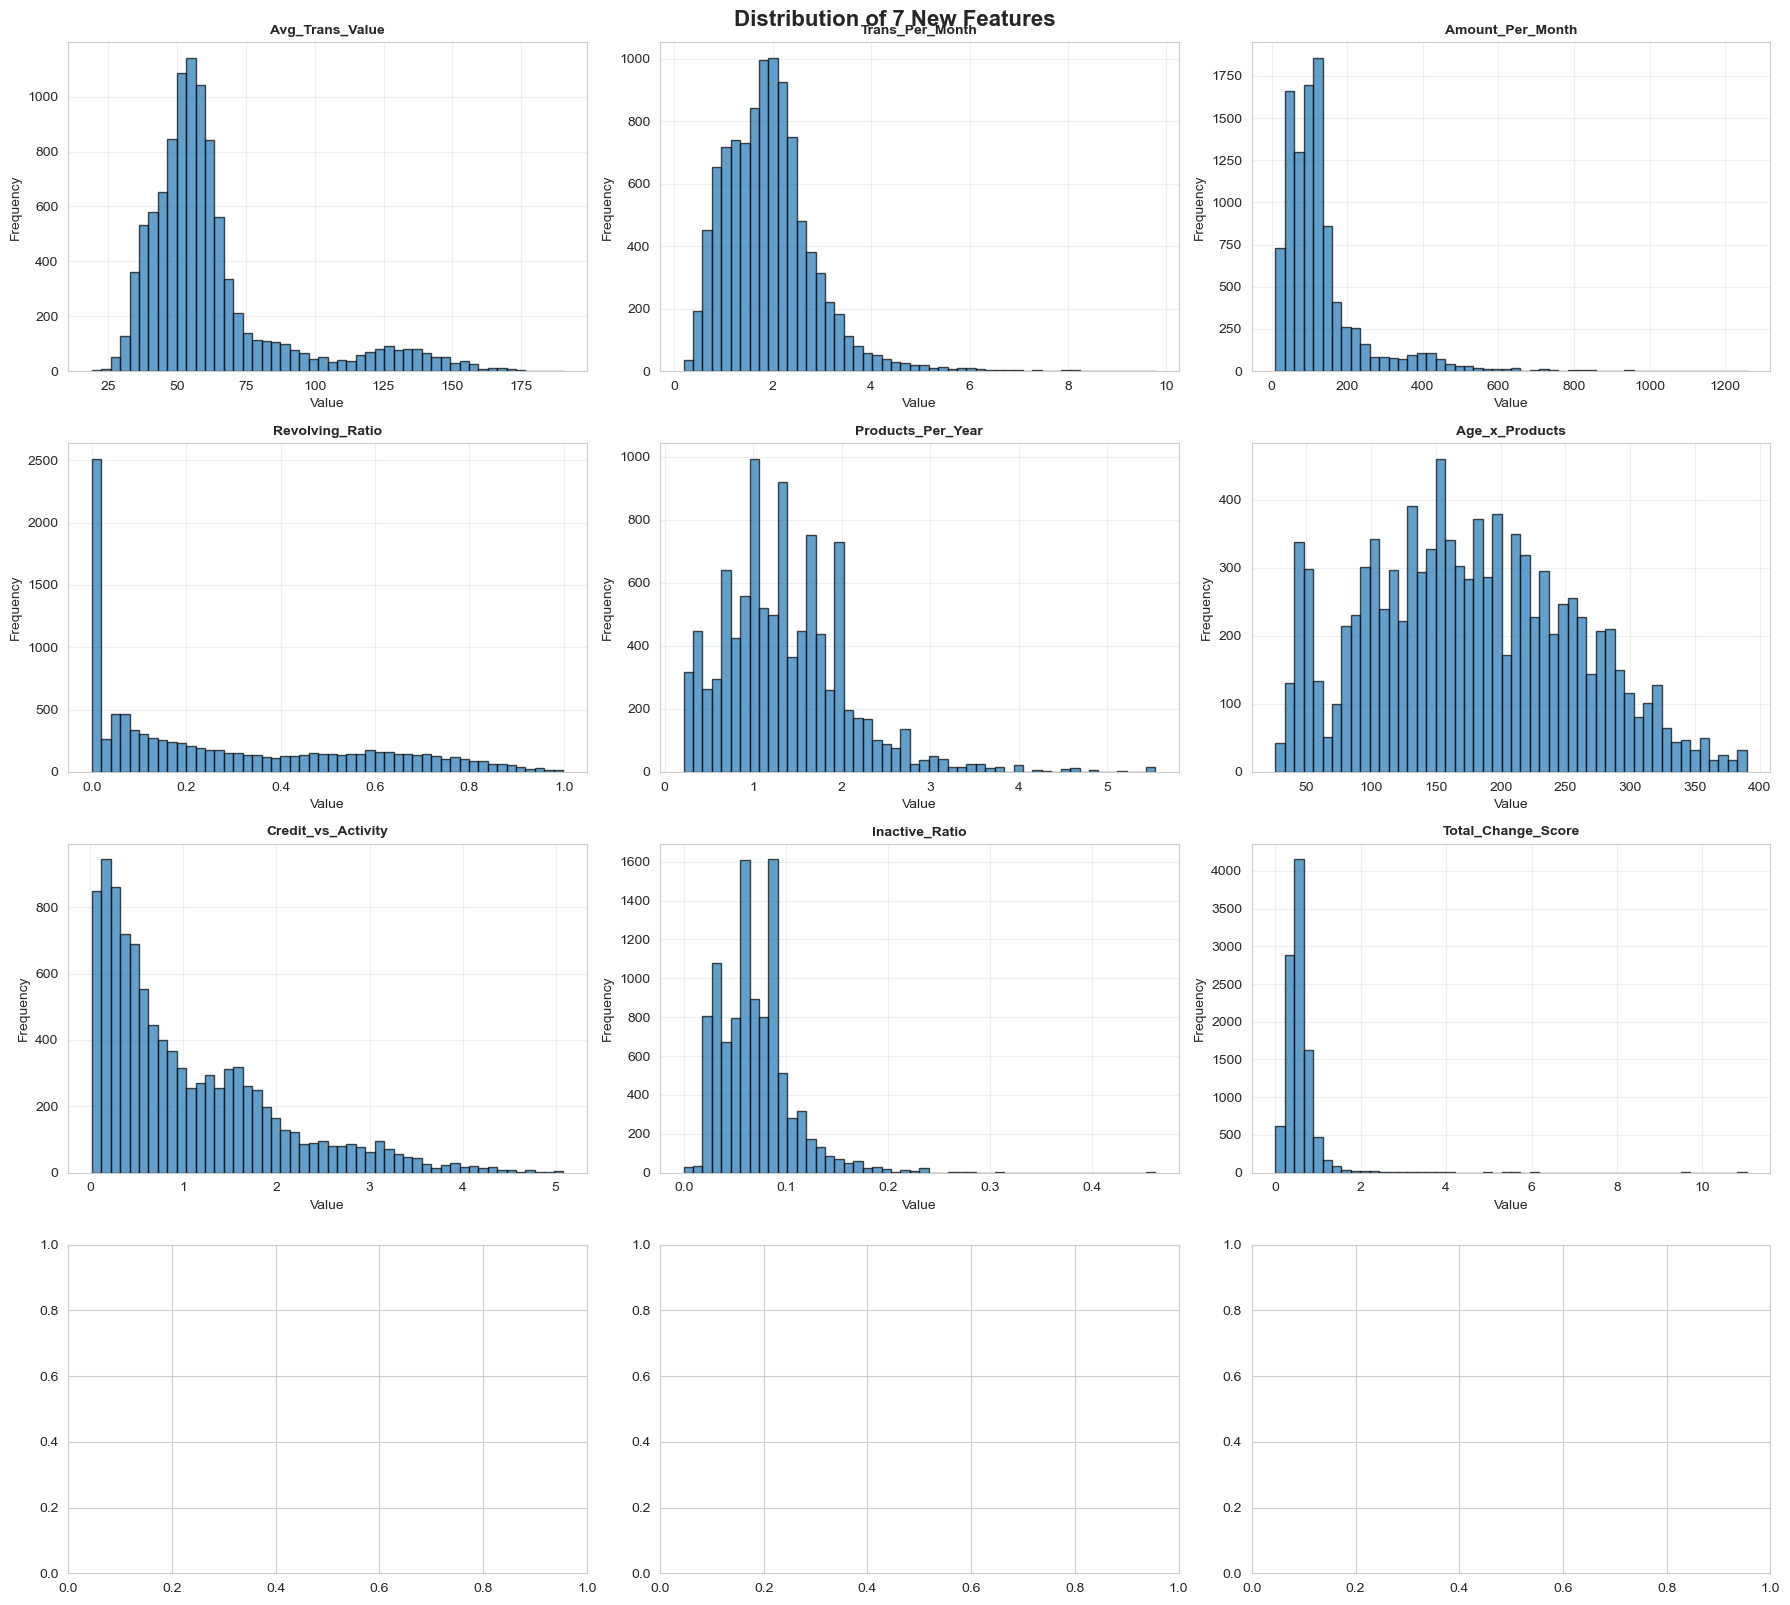

In [7]:
# visualisations

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.ravel()

for i, feature in enumerate(new_features):
    axes[i].hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of 7 New Features', fontsize=16, fontweight='bold', y=1.00)
plt.show()


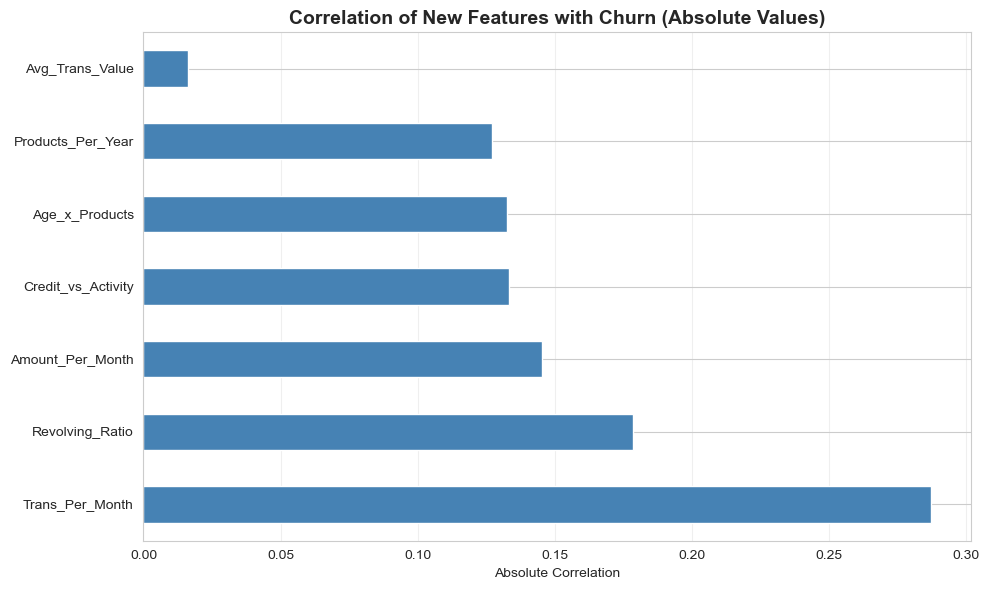


 5 new best features most correlated with churn:
   1. Trans_Per_Month (0.2872)
   2. Revolving_Ratio (0.1784)
   3. Amount_Per_Month (0.1453)
   4. Credit_vs_Activity (0.1332)
   5. Age_x_Products (0.1325)


In [17]:
# analyse de correlation

# Encode target
df['Attrition_Binary'] = df['Attrition_Flag'].map({
    'Attrited Customer': 1,
    'Existing Customer': 0
})

# Calculate correlations
correlations = df[new_features + ['Attrition_Binary']].corr()['Attrition_Binary'].drop('Attrition_Binary')
correlations_sorted = correlations.abs().sort_values(ascending=False)

# Visualize correlations
plt.figure(figsize=(10, 6))
correlations_sorted.plot(kind='barh', color='steelblue')
plt.title('Correlation of New Features with Churn (Absolute Values)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n 5 new best features most correlated with churn:")
top_5 = correlations_sorted.head(5)
for i, (feature, corr) in enumerate(top_5.items(), 1):
    print(f"   {i}. {feature} ({corr:.4f})")


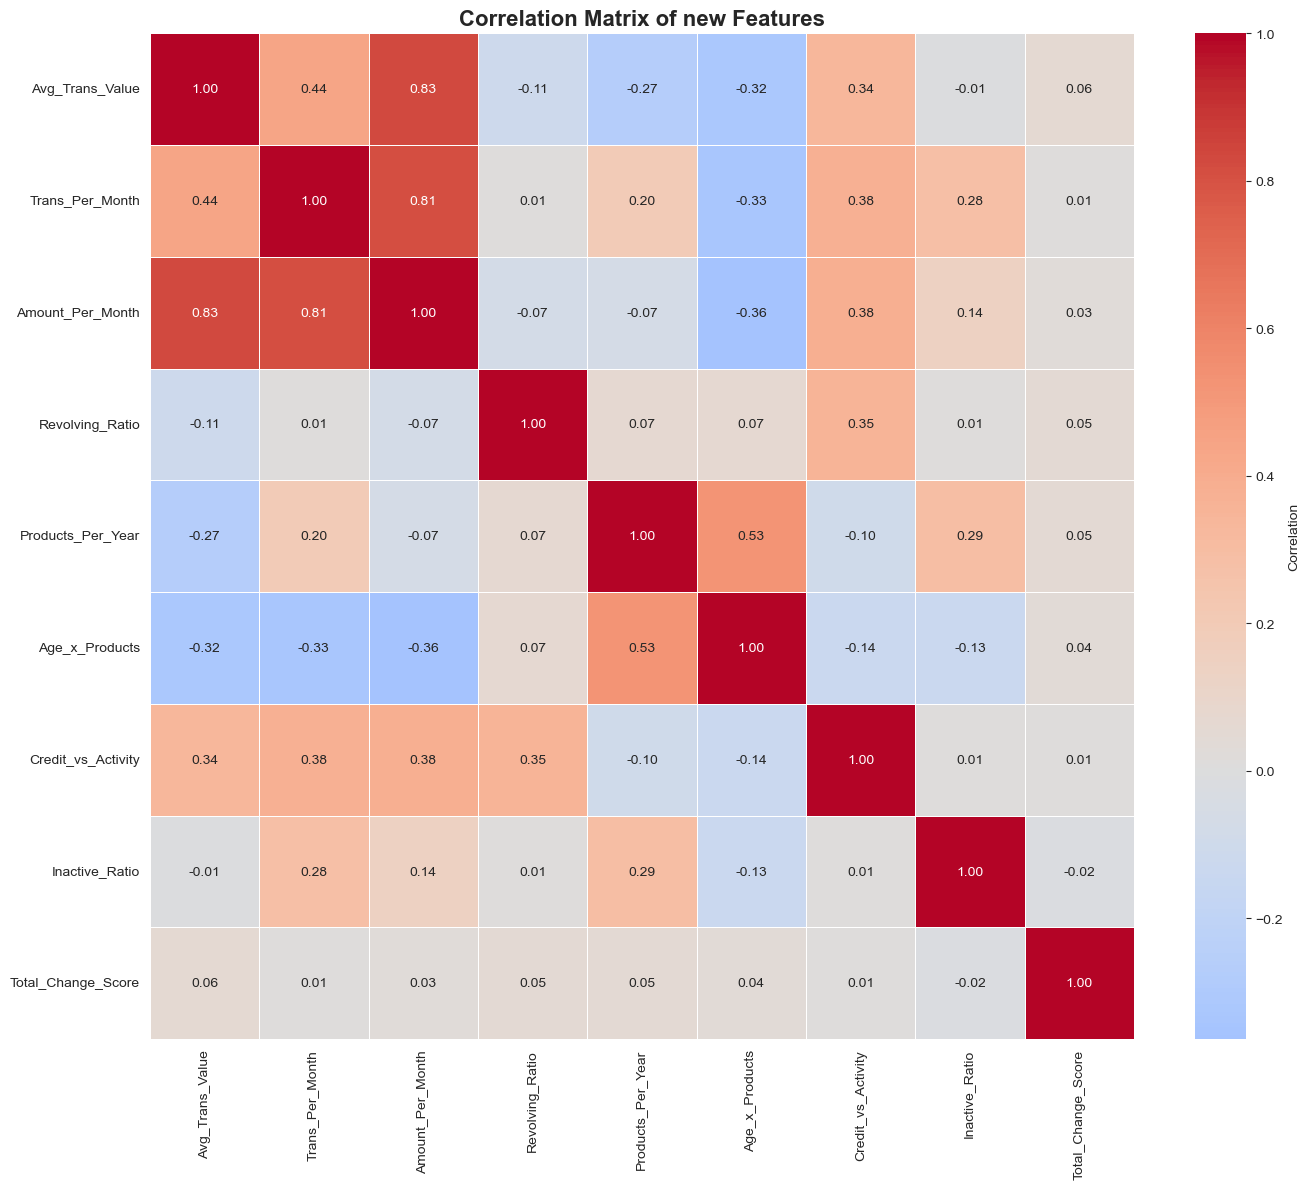

In [8]:
#heatmap

plt.figure(figsize=(14, 12))
corr_matrix = df[new_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of new Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Identify highly correlated pairs (>0.9)
print("\n Highly correlated feature pairs (correlation > 0.8):")
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = []
for column in upper_triangle.columns:
    for index in upper_triangle.index:
        if abs(upper_triangle.loc[index, column]) > 0.8:
            high_corr.append((index, column, upper_triangle.loc[index, column]))

if high_corr:
    for feat1, feat2, corr in high_corr:
        print(f"   • {feat1} <-> {feat2}: {corr:.4f}")
    print("\n Consider dropping one from each highly correlated pair")
else:
    print("    No highly correlated pairs found")


 Highly correlated feature pairs (correlation > 0.8):
   • Avg_Trans_Value <-> Amount_Per_Month: 0.8255
   • Trans_Per_Month <-> Amount_Per_Month: 0.8114

 Consider dropping one from each highly correlated pair


### Feature Engineering Strategy

We synthesized the team's proposals to select the most logical indicators from a banking business perspective:

1.  **Transactional Behavior (Average Basket & Frequency):**
    *   `Avg_Trans_Value`: Helps distinguish customers who make few transactions but with high amounts.
    *   `Trans_Per_Month` & `Amount_Per_Month`: Normalizes activity by customer tenure.

2.  **Engagement & Risk:**
    *   `Revolving_Ratio`: Credit card utilization rate (Debt / Limit). A high ratio may indicate risk or dependency.
    *   `Products_Per_Year`: Speed of adoption of banking products.
    *   `Inactive_Ratio`: Share of recent inactivity relative to the customer's total tenure.

3.  **Disengagement Signal (Churn):**
    *   `Total_Change_Score`: A composite variable (Interaction) combining the drop in amounts (Q4/Q1) AND the drop in frequency. If this score is low, the customer is slowing down activity on all fronts.

### Cleaning and Selection 
To avoid redundancy and noise, we remove certain initial variables that are highly correlated with others:
*   **Removal of `Avg_Open_To_Buy`**: Correlation of 0.99 with `Credit_Limit`. We keep `Credit_Limit` and the utilization ratio.
*   **Removal of `Transaction_Frequency_Per_Month`**: Mathematical duplicate of `Trans_Per_Month`.
*   **Removal of `Credit_vs_Activity`**: Almost zero correlation with the target (0.02).

In [6]:
def prepare_final_dataset(df_raw):
    df_final = df_raw.copy()
    
   # 1. Creating New Variables
    
    # Average basket (Amount / Number)
    df_final['Avg_Trans_Value'] = df_final['Total_Trans_Amt'] / (df_final['Total_Trans_Ct'] + 1e-6)
    
    # Monthly usage frequency
    df_final['Trans_Per_Month'] = df_final['Total_Trans_Ct'] / (df_final['Months_on_book'] + 1e-6)
    
    # Monthly Amount Spent
    df_final['Amount_Per_Month'] = df_final['Total_Trans_Amt'] / (df_final['Months_on_book'] + 1e-6)
    
    # Credit Utilization Rate (Revolving / Limit)
    df_final['Revolving_Ratio'] = df_final['Total_Revolving_Bal'] / (df_final['Credit_Limit'] + 1e-6)
    
    # Product Density (Products / Seniority)
    df_final['Products_Per_Year'] = df_final['Total_Relationship_Count'] / (df_final['Months_on_book'] + 1e-6)
    
    # Inactivity Ratio (Inactivity / Seniority)
    df_final['Inactive_Ratio'] = df_final['Months_Inactive_12_mon'] / (df_final['Months_on_book'] + 1e-6)
    
    # Overall Change Score (Amount x Frequency Interaction)
    df_final['Total_Change_Score'] = df_final['Total_Amt_Chng_Q4_Q1'] * df_final['Total_Ct_Chng_Q4_Q1']

   # 2. Selection and Cleaning
    
    # List of columns to remove (Redundant or ID)
    cols_to_drop = [
        'CLIENTNUM',                
        'Avg_Open_To_Buy',          
        'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
        'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
    ]
    
    df_final = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])
    
    return df_final

In [7]:
#Exécution 
# 1. Preparation of the complete dataset
df_final = prepare_final_dataset(df)

# 2. Séparation X (Features) et y (Target)
target_col = 'Attrition_Flag'
y = df_final[target_col].apply(lambda x: 1 if x == 'Attrited Customer' else 0)
X = df_final.drop(columns=[target_col])

print(f"Final form of dataset X : {X.shape}")
print(f"Colonnes conserved: {list(X.columns)}")

# 3. New Train/Test Split for the next steps
from sklearn.model_selection import train_test_split

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Forme finale du dataset X : (10127, 27)
Colonnes conservées : ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Avg_Trans_Value', 'Trans_Per_Month', 'Amount_Per_Month', 'Revolving_Ratio', 'Products_Per_Year', 'Age_x_Products', 'Credit_vs_Activity', 'Inactive_Ratio', 'Total_Change_Score']


### Modélisation avec le Nouveau Dataset

In [16]:
# Installation des modèles manquants
!pip install xgboost catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   --- ------------------------------------ 8.1/102.4 MB 40.6 MB/s eta 0:00:03
   ------ --------------------------------- 16.0/102.4 MB 41.6 MB/s eta 0:00:03
   --------- ------------------------------ 23.1/102.4 MB 37.9 MB/s eta 0:00:03
   ------------ --------------------------- 31.7/102.4 MB 38.7 MB/s eta 0:00:02
   --------------- ------------------------ 40.6/102.4 MB 39.7 MB/s eta 0:00:02
   ------------------ --------------------- 48.2/102.4 MB 39.2 MB/s eta 0:00:02
   ---------------------- ----------------- 57.7/102.4 MB 40.0 MB/s eta 0:00:02
   -------------------------- ------------- 66.6/102.4 MB 40.5 MB/s eta 0:00:01
   ----------------------------- ---------- 75.5/102.4 MB 40.8 MB/s eta 0:00:01
   --------------------------------- ------ 85.7/102.4 MB 41.8 MB/s eta 0:00:01
   ------------------------------------ --- 94.1/102.4 MB 41.8 MB/s eta 0:00:01
   --------------------------------------  102.2/1

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score, accuracy_score

In [9]:
# 1. DATA CHECKING AND PREPARATION
# Make sure we have DataFrames with the correct names
if not isinstance(X_train_eng, pd.DataFrame):
    X_train_eng = pd.DataFrame(X_train_eng, columns=X.columns)
    X_test_eng = pd.DataFrame(X_test_eng, columns=X.columns)
    
# Explicit identification of columns
numeric_features = X_train_eng.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_eng.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Features numériques ({len(numeric_features)}): {numeric_features[:3]}...")
print(f"Features catégorielles ({len(categorical_features)}): {categorical_features} \n")

Features numériques (22): ['Customer_Age', 'Dependent_count', 'Months_on_book']...
Features catégorielles (5): ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category'] 



In [10]:
# 2. DEFINITION OF THE PREPROCESSOR
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [11]:
# 3. DEFINITION OF MODEL PIPELINES
# Each model is encapsulated with the preprocessor
rf_pipe = Pipeline([('preprocessor', preprocessor), ('clf', RandomForestClassifier(n_estimators=200, random_state=42))])
gb_pipe = Pipeline([('preprocessor', preprocessor), ('clf', GradientBoostingClassifier(random_state=42))])
xgb_pipe = Pipeline([('preprocessor', preprocessor), ('clf', XGBClassifier(eval_metric='logloss', random_state=42))])
cat_pipe = Pipeline([('preprocessor', preprocessor), ('clf', CatBoostClassifier(verbose=0, random_state=42))])

#  Ensembles Models
dt_pipe = Pipeline([('preprocessor', preprocessor), ('clf', DecisionTreeClassifier())])
bagging_pipe = BaggingClassifier(estimator=dt_pipe, n_estimators=50, random_state=42)

# Voting 
voting_pipe = VotingClassifier(
    estimators=[('xgb', xgb_pipe), ('rf', rf_pipe), ('cat', cat_pipe)],
    voting='soft'
)

# Stacking
stacking_pipe = StackingClassifier(
    estimators=[('xgb', xgb_pipe), ('rf', rf_pipe), ('cat', cat_pipe)],
    final_estimator=LogisticRegression(),
    cv=3
)

In [12]:
#  4.TRAINING
models_list = [
    ("Random Forest", rf_pipe),
    ("Gradient Boost", gb_pipe),
    ("XGBoost", xgb_pipe),
    ("CatBoost", cat_pipe),
    ("Bagging", bagging_pipe),
    ("Voting", voting_pipe),
    ("Stacking", stacking_pipe)
]

results = []


for name, model in models_list:
    try:
        # Training
        model.fit(X_train_eng, y_train_eng)
        
        # Prédictions
        y_pred = model.predict(X_test_eng)
        y_proba = model.predict_proba(X_test_eng)[:, 1]
        
        #  score calculation 
        acc = accuracy_score(y_test_eng, y_pred)  
        f1 = f1_score(y_test_eng, y_pred)
        auc = roc_auc_score(y_test_eng, y_proba)
        recall = recall_score(y_test_eng, y_pred)
        acc=accuracy_score(y_test_eng,y_pred)
        
        # Stockage 
        results.append({
            "Modèle": name, 
            "Accuracy": acc,  
            "F1": f1, 
            "AUC": auc, 
            "Recall": recall
        })
        
        print(f" {name} : Acc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}")
        
    except Exception as e:
        print(f" Erreur avec {name}: {str(e)}")


✅ Random Forest : Acc=0.956 | F1=0.850 | AUC=0.987
✅ Gradient Boost : Acc=0.962 | F1=0.871 | AUC=0.988
✅ XGBoost : Acc=0.972 | F1=0.911 | AUC=0.992
✅ CatBoost : Acc=0.973 | F1=0.913 | AUC=0.992
 Erreur avec Bagging: Specifying the columns using strings is only supported for dataframes.
✅ Voting : Acc=0.973 | F1=0.911 | AUC=0.992
✅ Stacking : Acc=0.973 | F1=0.912 | AUC=0.992



 CLASSEMENT FINAL :


,Modèle,Accuracy,F1,AUC,Recall
3,CatBoost,0.973346,0.913183,0.992406,0.873846
5,Stacking,0.972853,0.911717,0.991802,0.873846
4,Voting,0.972853,0.911433,0.991636,0.870769
2,XGBoost,0.972359,0.911111,0.992055,0.883077
1,Gradient Boost,0.961500,0.870861,0.987889,0.809231
0,Random Forest,0.955577,0.850498,0.986629,0.787692


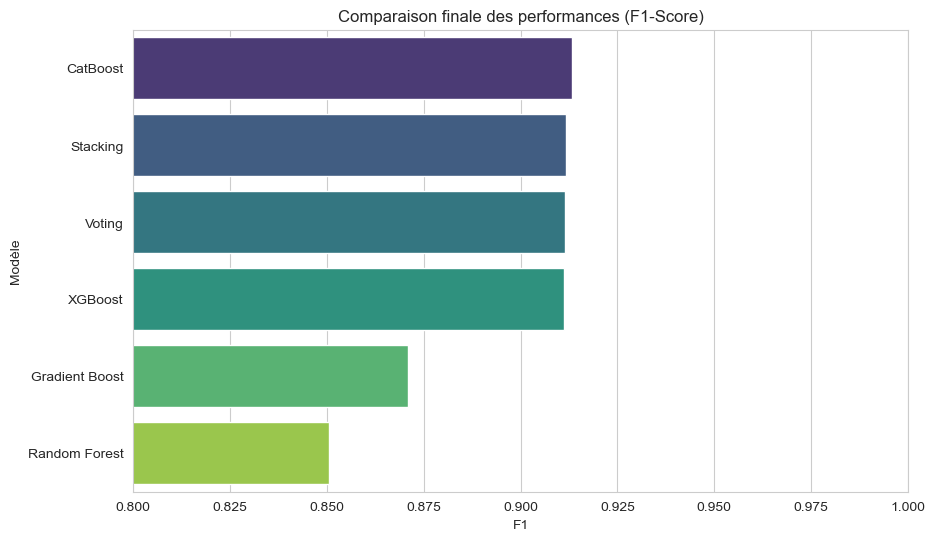

In [13]:
# 5. RÉSULTS 
df_results = pd.DataFrame(results).sort_values(by="F1", ascending=False)

print("\n Final ranking :")
display(df_results)

# Graph
if not df_results.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x="F1", y="Modèle", data=df_results, palette="viridis")
    plt.title("Final comparison (F1-Score)")
    plt.xlim(0.8, 1.0)
    plt.show()

## Interpretability

In [14]:
!pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 2.9 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [40]:
import shap

#1. Préparation of data for SHAP 
preprocessor.fit(X_train_eng)

# we transform the data (X_train et X_test) in numeric format for  SHAP
X_train_transformed = preprocessor.transform(X_train_eng)
X_test_transformed = preprocessor.transform(X_test_eng)

# We retrieve the feature names after transformation (important for charts)
# Trick to get the column names from the OneHotEncoder
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    num_names = numeric_features
    cat_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
    feature_names = np.r_[num_names, cat_names]

# Conversion to DataFrame for SHAP
X_test_shap_df = pd.DataFrame(X_test_transformed, columns=feature_names)


# 2. Retraining the CatBoost model
# We use the same hyperparameters as in the pipeline
best_model = CatBoostClassifier(verbose=0, random_state=42)
best_model.fit(X_train_transformed, y_train_eng)

print(" CatBoost Ready ")


# 3. Calculating SHAP values
# The Explainer will analyze the model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_shap_df)

print("Valeurs SHAP calculated")


 CatBoost Ready 
Valeurs SHAP calculated


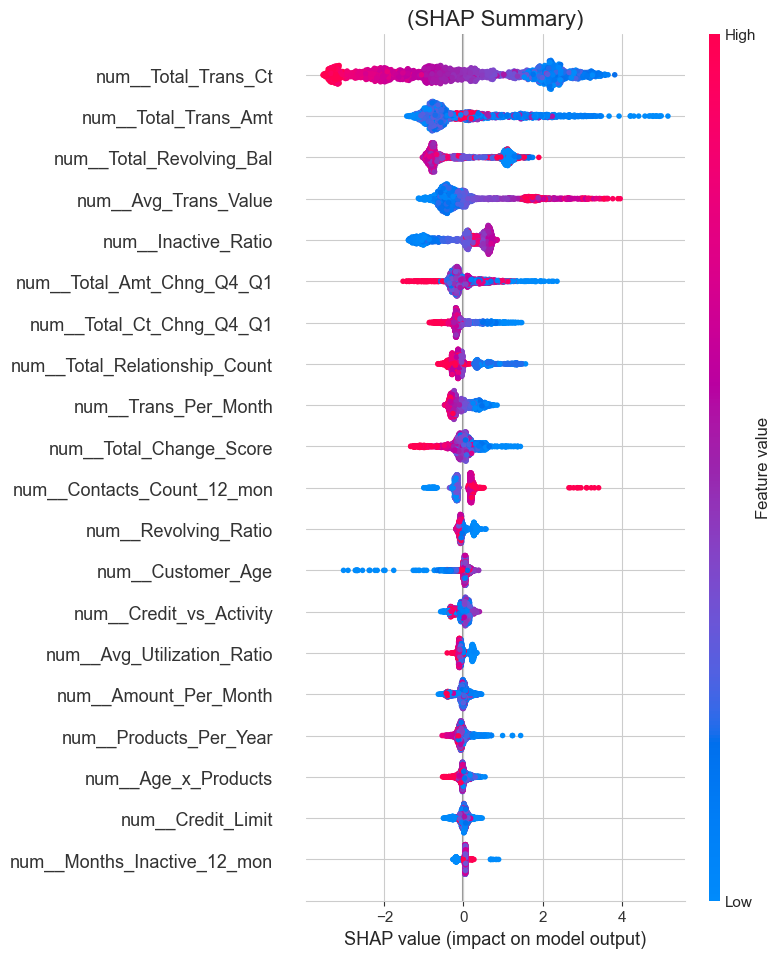

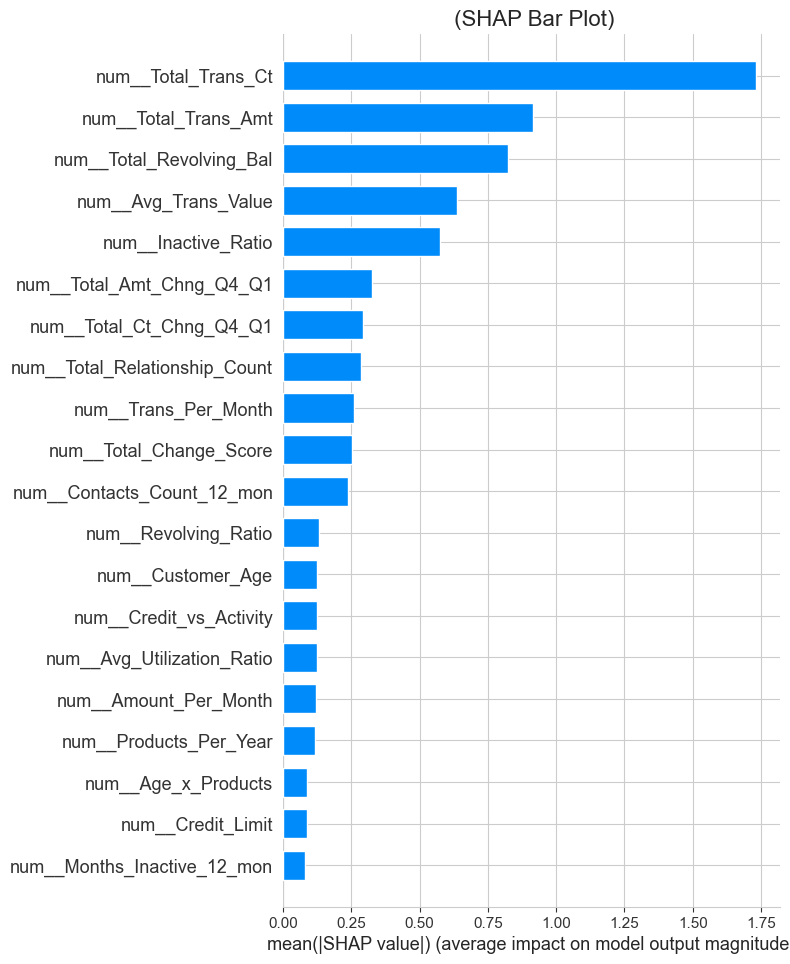

In [39]:
#4. Visualisation

# Graph 1 : Summary Plot 
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_shap_df, show=False)
plt.title("(SHAP Summary)", fontsize=16)
plt.show()

# Graph 2 : Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_shap_df, plot_type="bar", show=False)
plt.title(" (SHAP Bar Plot)", fontsize=16)
plt.show()

### SHAP Analysis: Understanding Why Customers Churn

To make our model transparent and actionable, we used **SHAP (SHapley Additive exPlanations)** values. This analysis reveals *which* factors drive the model's decisions.

The results highlight three main drivers of churn:

1.  **Total_Trans_Ct:** This is the strongest predictor. Customers who make fewer transactions are much more likely to leave. A drop in usage frequency is a major red flag.
2.  **Total_Revolving_Bal:** Surprisingly, customers with *lower* credit card debt are more likely to churn. Those with higher balances are financially "locked in" and tend to stay loyal.
3.  **Avg_Trans_Value:** Our new engineered feature proved critical. Customers with smaller average transaction amounts are at higher risk.

In short, **low activity** and **low financial engagement** are the clearest signals that a customer is about to leave.

## Analysis

In [38]:
#5. Analysis of Errors (Business Insights)

# Redoing the final predictions
y_pred_final = best_model.predict(X_test_transformed)

# Creating an analysis DataFrame
analysis_df = X_test_eng.copy()
analysis_df['True_Label'] = y_test_eng.values
analysis_df['Predicted_Label'] = y_pred_final

# Identification of False Negatives (Clients who left but were predicted to stay)
false_negatives = analysis_df[(analysis_df['True_Label'] == 1) & (analysis_df['Predicted_Label'] == 0)]
# Identification of True Positives (Customers who left and were correctly detected)
true_positives = analysis_df[(analysis_df['True_Label'] == 1) & (analysis_df['Predicted_Label'] == 1)]

print(f"Number of customers MISSED by the model: {len(false_negatives)}")
print(f"Number of clients who left DETECTED by the model: {len(true_positives)}")

# Comparison of profils (Mean)
comparison = pd.DataFrame({
    'Missed Departed Clients (Errors)': false_negatives.mean(numeric_only=True),
    'Departed Clients DETECTED (Success)': true_positives.mean(numeric_only=True),
    'Loyal Customers (Remaining)': analysis_df[analysis_df['True_Label'] == 0].mean(numeric_only=True)
})

print("\nComparison of profiles")
key_vars = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal', 'Avg_Trans_Value', 'Inactive_Ratio']
display(comparison.loc[key_vars])

Number of customers MISSED by the model: 41
Number of clients who left DETECTED by the model: 284

Comparison of profiles


,Missed Departed Clients (Errors),Departed Clients DETECTED (Success),Loyal Customers (Remaining)
Total_Trans_Ct,51.658537,45.461268,69.162257
Total_Trans_Amt,3110.634146,3338.778169,4689.428571
Total_Revolving_Bal,1074.975610,630.017606,1230.750735
Avg_Trans_Value,55.610784,67.256205,62.457508
Inactive_Ratio,0.058605,0.075593,0.067731
